In [3]:
#!/usr/bin/env python
"""PHASE 5b - Difficulty-Axis Arms. Single self-contained cell.

Assembled from the Phase 5 notebook, Section 10 replaced with the four-arm
selector. Defines EVERYTHING in one go - kernel restarts and cell order do
not matter. Reporting cells are DEFINITIONS ONLY; their original top-level
invocations are driven by report_all() after a run instead.
Fixed constants untouched. SELECTION_MODE="hard" reproduces Phase 5.
"""


# ── Standard library ──────────────────────────────────────────────
import os
import sys
import glob
import json
import time
import random
import inspect
import hashlib
import importlib.util
from collections import defaultdict

# ── Third party ───────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import f1_score
from scipy import stats as sps
import matplotlib.pyplot as plt

# ── Fixed constants: verbatim from Phase 2, do not edit ───────────
SEEDS = [42, 123, 456, 789, 1011]
SUBSET_FRACS = [0.002, 0.005, 0.01, 0.02, 0.05]
EPOCHS = {"mnist": 20, "cifar10": 30}
BATCH_SIZE = 128
NUM_WORKERS = 2
LR = 1e-3
WEIGHT_DECAY = 1e-4
SCHED_FACTOR = 0.5
SCHED_PATIENCE = 3
N_CLASSES = 10

MNIST_NORM = ((0.1307,), (0.3081,))
CIFAR_NORM = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

# Locked parameter counts. The 576 difference is exactly the first conv layer's two extra
# input channels: 32 filters x 2 channels x 3 x 3 = 576.
EXPECTED_PARAMS = {"mnist": 227_018, "cifar10": 227_594}

# Phase 5 uses lowercase dataset keys throughout. Phase 3's display helper expects the
# uppercase spelling, so Section 12 maps between them rather than editing that helper.
DISPLAY_NAME = {"mnist": "MNIST", "cifar10": "CIFAR10"}
CLASS_NAMES = {
    "mnist": [str(d) for d in range(10)],
    "cifar10": ["airplane", "automobile", "bird", "cat", "deer",
                "dog", "frog", "horse", "ship", "truck"],
}

# ── Paths ─────────────────────────────────────────────────────────
DATA_DIR = "/kaggle/working/data"
OUT_DIR = "/kaggle/working/phase5"
RESULTS_DIR = f"{OUT_DIR}/results"
FIG_DIR = f"{OUT_DIR}/figures"
for _d in (DATA_DIR, OUT_DIR, RESULTS_DIR, FIG_DIR):
    os.makedirs(_d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device {DEVICE}")
if DEVICE.type == "cuda":
    print(f"gpu: {torch.cuda.get_device_name(0)}")

# ── Shared model script ───────────────────────────────────────────
SCRIPT_PATH = ("/kaggle/input/notebooks/nareshgudipalli/"
               "dissertation-cnn-script/__script__.py")
if not os.path.exists(SCRIPT_PATH):
    raise FileNotFoundError(
        f"Shared model script not found at {SCRIPT_PATH}.\n"
        "Add Input -> Notebook Output -> 'nareshgudipalli/dissertation-cnn-script'.\n"
        "Attach it as a NOTEBOOK, not as a Dataset."
    )
sys.path.append(os.path.dirname(SCRIPT_PATH))
_spec = importlib.util.spec_from_file_location("model", SCRIPT_PATH)
model_module = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(model_module)
SimpleCNN = model_module.SimpleCNN
print(f"SimpleCNN loaded | signature: {inspect.signature(SimpleCNN.__init__)}")


def stage_dataset(pattern: str, dest_name: str, label: str):
    """Symlink an already-extracted dataset directory into DATA_DIR if one is attached.

    Returns True if staging succeeded, False if torchvision should download instead.
    """
    hits = glob.glob(pattern, recursive=True)
    if not hits:
        print(f"  {label}: not found in inputs -> torchvision will download")
        return False
    src = sorted(hits)[0]
    dest = os.path.join(DATA_DIR, dest_name)
    if os.path.exists(dest) or os.path.islink(dest):
        print(f"  {label}: already staged at {dest}")
        return True
    os.symlink(src, dest)
    print(f"  {label}: staged {src} -> {dest}")
    return True


print("Staging datasets:")
stage_dataset("/kaggle/input/**/MNIST/raw", "MNIST", "MNIST")
stage_dataset("/kaggle/input/**/cifar-10-batches-py", "cifar-10-batches-py", "CIFAR-10")


def set_seed(seed: int):
    """Fix all random sources in the main process."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int):
    """Fix the RNG inside each DataLoader worker subprocess."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_generator(seed: int) -> torch.Generator:
    """Seeded generator controlling DataLoader shuffle order."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g


def get_transforms(dataset_name: str, train: bool):
    """Return the transform pipeline. Verbatim from Phase 2."""
    if dataset_name == "mnist":
        # MNIST is never augmented, in any phase.
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(*MNIST_NORM),
        ])
    if train:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(*CIFAR_NORM),
        ])
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(*CIFAR_NORM),
    ])


def build_dataset(dataset_name: str, train: bool, augment: bool):
    """Augmentation is applied only when train=True AND augment=True."""
    tf = get_transforms(dataset_name, train=(augment and train))
    cls = datasets.MNIST if dataset_name == "mnist" else datasets.CIFAR10
    return cls(root=DATA_DIR, train=train, download=True, transform=tf)


def get_labels(dataset_name: str) -> np.ndarray:
    ds = build_dataset(dataset_name, train=True, augment=False)
    return np.asarray(ds.targets, dtype=np.int64)


class IndexedDataset(Dataset):
    """Wrap a dataset so each item carries its own index.

    Required to attribute per-example forgetting statistics back to dataset positions.
    Touches nothing else about the underlying data.
    """

    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, y = self.base[i]
        return x, y, i


def _unwrap(dataset):
    """Strip IndexedDataset / Subset wrappers to reach the torchvision dataset."""
    d = dataset
    while True:
        if isinstance(d, IndexedDataset):
            d = d.base
        elif isinstance(d, Subset):
            d = d.dataset
        else:
            return d


def infer_dataset_name(dataset) -> str:
    """Let sample_indices keep its fixed 3-argument signature by inferring the dataset."""
    d = _unwrap(dataset)
    if isinstance(d, datasets.MNIST):
        return "mnist"
    if isinstance(d, datasets.CIFAR10):
        return "cifar10"
    raise TypeError(f"Unrecognised dataset type: {type(d)}")


# ── Divisibility assertion ────────────────────────────────────────
for _ds in ("mnist", "cifar10"):
    _lab = get_labels(_ds)
    _counts = np.bincount(_lab)
    print(f"{_ds}: N={len(_lab)}  class counts min={_counts.min()} max={_counts.max()}")
    for _f in SUBSET_FRACS:
        _tot = int(round(_f * len(_lab)))
        assert _tot % N_CLASSES == 0, f"{_ds} f={_f}: n_total={_tot} not divisible by 10"
        print(f"    {_f*100:>4g}% -> {_tot:>5} total, {_tot // N_CLASSES:>4} per class")


_SIG_PARAMS = inspect.signature(SimpleCNN.__init__).parameters


def build_model(dataset_name: str) -> nn.Module:
    """Instantiate the shared SimpleCNN and verify it against locked parameter counts."""
    in_ch = 1 if dataset_name == "mnist" else 3
    kwargs = {}
    for name in ("in_channels", "input_channels", "n_channels", "num_channels", "channels"):
        if name in _SIG_PARAMS:
            kwargs[name] = in_ch
            break
    for name in ("num_classes", "n_classes"):
        if name in _SIG_PARAMS:
            kwargs[name] = N_CLASSES
            break

    model = SimpleCNN(**kwargs)
    n_params = sum(p.numel() for p in model.parameters())
    expected = EXPECTED_PARAMS[dataset_name]
    if n_params != expected:
        raise RuntimeError(
            f"Parameter-count mismatch for {dataset_name}: got {n_params:,}, "
            f"expected {expected:,}. Resolved kwargs: {kwargs}. "
            "The architecture must be byte-identical to Phase 1."
        )
    return model


for _ds in ("mnist", "cifar10"):
    _m = build_model(_ds)
    print(f"  {_ds}: {sum(p.numel() for p in _m.parameters()):,} parameters  [matches locked count]")
del _m


CONFIG_FIELDS = dict(
    arch="SimpleCNN", opt="adam", lr=LR, wd=WEIGHT_DECAY,
    sched="plateau_train_loss", factor=SCHED_FACTOR, patience=SCHED_PATIENCE,
    batch=BATCH_SIZE, phase=5,
)
CONFIG_HASH = hashlib.md5(json.dumps(CONFIG_FIELDS, sort_keys=True).encode()).hexdigest()[:10]
print(f"config hash: {CONFIG_HASH}")


def stats_path(dataset_name: str, seed: int, epochs=None) -> str:
    """Cache path. The epoch count is IN THE FILENAME - see the incident note above."""
    epochs = EPOCHS[dataset_name] if epochs is None else epochs
    return os.path.join(
        OUT_DIR, f"forgetting_{dataset_name}_seed{seed}_e{epochs}_{CONFIG_HASH}.npz")


def run_instrumented_training(dataset_name: str, seed: int, epochs=None, verbose=True) -> str:
    """Train on the FULL training set, logging per-example correctness every presentation.

    Records both the `aug` variant (Toneva Algorithm 1, from the training forward pass) and the
    `clean` variant (eval-mode pass over un-augmented data at each epoch boundary).
    """
    epochs = EPOCHS[dataset_name] if epochs is None else epochs
    set_seed(seed)

    train_aug = build_dataset(dataset_name, train=True, augment=True)
    train_clean = build_dataset(dataset_name, train=True, augment=False)
    labels = get_labels(dataset_name)
    N = len(train_aug)

    loader = DataLoader(
        IndexedDataset(train_aug), batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, worker_init_fn=seed_worker, generator=make_generator(seed),
        pin_memory=True, drop_last=False)
    clean_loader = DataLoader(
        IndexedDataset(train_clean), batch_size=512, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    model = build_model(dataset_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE)

    # prev_*  : accuracy at this example's previous presentation
    # forget_*: running count of correct -> incorrect transitions
    # learned_*: has this example EVER been correct? (drives the sentinel)
    prev_aug = np.zeros(N, dtype=np.int8)
    forget_aug = np.zeros(N, dtype=np.int32)
    learned_aug = np.zeros(N, dtype=bool)
    prev_clean = np.zeros(N, dtype=np.int8)
    forget_clean = np.zeros(N, dtype=np.int32)
    learned_clean = np.zeros(N, dtype=bool)

    history = []
    t0 = time.time()

    for epoch in range(epochs):
        # ── aug variant: Toneva Algorithm 1, free from the training forward pass ──
        model.train()
        running_loss, n_batches, n_correct = 0.0, 0, 0
        for x, y, idx in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            out = model(x)                    # forward pass, model state BEFORE this update
            loss = criterion(out, y)

            with torch.no_grad():
                acc = (out.argmax(1) == y).to(torch.int8).cpu().numpy()
            i = idx.numpy()
            forget_aug[i] += (prev_aug[i] > acc).astype(np.int32)   # 1 -> 0 transition
            learned_aug[i] |= (acc == 1)
            prev_aug[i] = acc
            n_correct += int(acc.sum())

            optimiser.zero_grad()             # gradient step happens AFTER the bookkeeping
            loss.backward()
            optimiser.step()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / n_batches
        scheduler.step(train_loss)            # steps on TRAINING loss - no validation split

        # ── clean variant: eval-mode robustness pass ──
        model.eval()
        n_correct_clean = 0
        with torch.no_grad():
            for x, y, idx in clean_loader:
                x = x.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                acc = (model(x).argmax(1) == y).to(torch.int8).cpu().numpy()
                i = idx.numpy()
                forget_clean[i] += (prev_clean[i] > acc).astype(np.int32)
                learned_clean[i] |= (acc == 1)
                prev_clean[i] = acc
                n_correct_clean += int(acc.sum())

        history.append(dict(epoch=epoch + 1, train_loss=train_loss,
                            train_acc_aug=n_correct / N, train_acc_clean=n_correct_clean / N,
                            lr=optimiser.param_groups[0]["lr"]))
        if verbose:
            print(f"  [{dataset_name} s{seed}] epoch {epoch+1:>2}/{epochs} "
                  f"loss {train_loss:.4f} | train-acc(aug) {n_correct/N:.4f} "
                  f"| train-acc(clean) {n_correct_clean/N:.4f} "
                  f"| never-learned(aug) {int((~learned_aug).sum()):>6}")

    path = stats_path(dataset_name, seed, epochs)
    np.savez_compressed(
        path,
        forget_aug=forget_aug, learned_aug=learned_aug,
        forget_clean=forget_clean, learned_clean=learned_clean,
        labels=labels, epochs=np.int32(epochs), seed=np.int32(seed),
        history=json.dumps(history), config_hash=CONFIG_HASH)
    if verbose:
        print(f"  saved -> {os.path.basename(path)}  ({time.time()-t0:.1f}s)")
    return path


FORGETTING_STORE = {}       # (dataset_name, seed, variant) -> dict of arrays
SELECTION_VARIANT = "aug"   # pre-registered primary; "clean" only for the robustness re-run


def finalize_counts(forget: np.ndarray, learned: np.ndarray) -> np.ndarray:
    """Apply Toneva's sentinel: never-learned examples sort as infinitely forgotten."""
    counts = forget.astype(np.float64)
    counts[~learned] = np.inf
    return counts


def load_forgetting_stats(dataset_name: str, seed: int, epochs=None) -> str:
    """Load a cached .npz into FORGETTING_STORE for both variants."""
    path = stats_path(dataset_name, seed, epochs)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"No forgetting statistics at {os.path.basename(path)}. Run Section 15 first.")
    z = np.load(path, allow_pickle=False)
    labels = z["labels"]
    for variant in ("aug", "clean"):
        FORGETTING_STORE[(dataset_name, seed, variant)] = dict(
            counts=finalize_counts(z[f"forget_{variant}"], z[f"learned_{variant}"]),
            raw=z[f"forget_{variant}"].copy(),
            learned=z[f"learned_{variant}"].copy(),
            labels=labels.copy())
    return path


# ── Self-test of the sentinel, on synthetic data ──────────────────
_forget = np.array([0, 5, 2, 9, 0, 3, 7, 1, 0, 4], dtype=np.int32)
_learned = np.array([1, 1, 1, 1, 0, 1, 1, 1, 0, 1], dtype=bool)
_counts = finalize_counts(_forget, _learned)
_order = np.lexsort((np.random.default_rng(0).random(10), -_counts))
assert np.isinf(_counts[_order[:2]]).all(), "never-learned must rank first"
assert list(_counts[_order[2:]]) == [9, 7, 5, 4, 3, 2, 1, 0], "finite counts must be descending"
print("Sentinel self-test PASSED")
print(f"  raw       : {_forget}")
print(f"  learned   : {_learned.astype(int)}")
print(f"  finalised : {_counts}")
print(f"  hardest-first order: {_order}  -> counts {_counts[_order]}")


def never_learned_diagnostic(dataset_name: str, variant: str = "aug", seeds=None) -> list:
    """Per-class never-learned counts against the per-class quota at each subset size.

    `seeds` must be the seeds actually present in FORGETTING_STORE for this run.
    """
    seeds = SEEDS if seeds is None else seeds
    rows = []
    N = len(FORGETTING_STORE[(dataset_name, seeds[0], variant)]["labels"])
    for seed in seeds:
        st = FORGETTING_STORE[(dataset_name, seed, variant)]
        counts = st["counts"]
        for c in range(N_CLASSES):
            cls = np.where(st["labels"] == c)[0]
            n_never = int(np.isinf(counts[cls]).sum())
            finite = counts[cls][np.isfinite(counts[cls])]
            row = dict(dataset=dataset_name, variant=variant, seed=seed, cls=c,
                       class_name=CLASS_NAMES[dataset_name][c],
                       n_class=len(cls), n_never_learned=n_never,
                       max_finite_forget=float(finite.max()) if finite.size else float("nan"))
            for f in SUBSET_FRACS:
                quota = int(round(f * N)) // N_CLASSES
                row[f"quota_{f}"] = quota
                row[f"sentinel_frac_{f}"] = min(n_never, quota) / quota
            rows.append(row)
    return rows


def summarise_never_learned(rows: list, dataset_name: str, variant: str = "aug"):
    """Print the diagnostic table, class-ordered by Phase 1 F1 ascending (Maier's rule)."""
    sub = [r for r in rows if r["dataset"] == dataset_name and r["variant"] == variant]
    if not sub:
        return
    order = canonical_class_order(dataset_name)
    print(f"\n{'='*84}")
    print(f"NEVER-LEARNED DIAGNOSTIC - {dataset_name}, variant={variant} (mean over seeds)")
    print(f"{'='*84}")
    print(f"{'class':<12}{'n_never':>9}" + "".join(f"{'sf@'+str(f):>10}" for f in SUBSET_FRACS))
    for c in order:
        rs = [r for r in sub if r["cls"] == c]
        line = f"{CLASS_NAMES[dataset_name][c]:<12}{np.mean([r['n_never_learned'] for r in rs]):>9.1f}"
        for f in SUBSET_FRACS:
            line += f"{np.mean([r['sentinel_frac_'+str(f)] for r in rs]):>10.2f}"
        print(line)
    print("sf@f = fraction of that class's quota drawn from the infinite-sentinel tier.")
    print("1.00 means selection at that size is a random draw among never-learned examples.")


# ============================================================================
# Section 10 - Selection Functions  [PHASE 5b: difficulty-axis arms]
# ----------------------------------------------------------------------------
# Phase 5 selected the HARDEST examples and failed, because at small subset
# sizes the selection collapsed entirely into the never-learned sentinel tier
# (sentinel_frac = 1.00). Phase 5b asks whether that failure belongs to the
# difficulty axis as a whole, or only to its extreme upper end.
#
# Only the RANKING KEY changes. Quota logic, seeding, and the sorted() return
# are identical to Phase 5, so every arm stays comparable to Phases 2-5.
# SELECTION_MODE = "hard" reproduces Phase 5's selection byte-identically.
# ============================================================================

SELECTION_MODE = "hard"                                   # set before each run
VALID_MODES = ("hard", "easy", "mid", "hard_ns")


def per_class_quota(n_total: int, n_classes: int = None) -> int:
    """Phase 3 quota logic. Exact integer division - verified in Section 4.
    n_classes resolves at CALL time so this does not depend on cell order."""
    if n_classes is None:
        n_classes = N_CLASSES
    assert n_total % n_classes == 0, f"n_total={n_total} not divisible by {n_classes}"
    return n_total // n_classes


def _class_order(counts_c, rng, mode: str):
    """Ordering of within-class positions, best-first for the given mode.

    Ties are ALWAYS broken by the seeded rng, never by index order - index
    order would make selection depend on dataset storage layout (a confound).
    """
    tie = rng.random(counts_c.size)

    if mode == "hard":
        # Descending; inf (never-learned) first. Phase 5 behaviour, unchanged.
        return np.lexsort((tie, -counts_c))

    if mode == "easy":
        # Ascending; zero-forgetting first, inf last (inf is the largest value).
        return np.lexsort((tie, counts_c))

    if mode == "hard_ns":
        # Descending over FINITE counts only. Sentinels pushed to the back so
        # they are used only if the class pool would otherwise run dry.
        key = np.where(np.isinf(counts_c), -np.inf, counts_c)
        return np.lexsort((tie, -key))

    if mode == "mid":
        # Nearest to the per-class median of counts that are BOTH finite AND
        # non-zero. The zero tier must be excluded: a converged network leaves
        # the majority of examples never forgotten, so median(all finite) = 0
        # and a median-centred rule silently degenerates into the "easy" arm.
        pool = counts_c[np.isfinite(counts_c) & (counts_c > 0)]
        if pool.size == 0:
            return np.lexsort((tie,))
        median = np.median(pool)
        eligible = np.isfinite(counts_c) & (counts_c > 0)
        dist = np.where(eligible, np.abs(counts_c - median), np.inf)
        return np.lexsort((tie, dist))

    raise ValueError(f"unknown SELECTION_MODE {mode!r}, expected one of {VALID_MODES}")


def sample_indices(dataset, fraction: float, seed: int) -> list:
    """Per-class selection by forgetting count under the active SELECTION_MODE."""
    assert SELECTION_MODE in VALID_MODES, f"bad SELECTION_MODE {SELECTION_MODE!r}"

    dataset_name = infer_dataset_name(dataset)
    store = FORGETTING_STORE[(dataset_name, seed, SELECTION_VARIANT)]
    counts, labels = store["counts"], store["labels"]

    quota = per_class_quota(int(round(fraction * len(labels))))
    rng = np.random.default_rng(seed)

    selected = []
    for c in range(N_CLASSES):
        cls_idx = np.where(labels == c)[0]
        assert cls_idx.size >= quota, f"class {c}: pool {cls_idx.size} < quota {quota}"
        order = _class_order(counts[cls_idx], rng, SELECTION_MODE)
        selected.extend(cls_idx[order[:quota]].tolist())
    return sorted(selected)


def selection_report(dataset_name: str, seed: int, fraction: float, indices: list) -> dict:
    """Tier composition of a selection.

    frac_zero_forget is the mirror of frac_from_sentinel: together they detect
    tie-pool collapse at EITHER end of the difficulty axis.
    """
    sel = FORGETTING_STORE[(dataset_name, seed, SELECTION_VARIANT)]["counts"][np.asarray(indices)]
    finite = sel[np.isfinite(sel)]
    return dict(dataset=dataset_name, seed=seed, fraction=fraction, mode=SELECTION_MODE,
                n_selected=len(indices),
                frac_from_sentinel=float(np.isinf(sel).mean()),
                frac_zero_forget=float((sel == 0).mean()),
                mean_finite_forget=float(finite.mean()) if finite.size else float("nan"),
                min_finite_forget=float(finite.min()) if finite.size else float("nan"),
                max_finite_forget=float(finite.max()) if finite.size else float("nan"))


print(f"Section 10 loaded. SELECTION_MODE = {SELECTION_MODE!r}  (options: {VALID_MODES})")


def test_selection(dataset_name: str, seed: int, fractions=None):
    """Size, quota, uniqueness and determinism checks."""
    fractions = SUBSET_FRACS if fractions is None else fractions
    ds = build_dataset(dataset_name, train=True, augment=False)
    labels = get_labels(dataset_name)
    N = len(labels)
    print(f"\nSelection tests - {dataset_name}, seed {seed}")
    for f in fractions:
        idx = sample_indices(ds, f, seed)
        expected_total = int(round(f * N))
        expected_quota = expected_total // N_CLASSES
        assert len(idx) == expected_total, f"size {len(idx)} != {expected_total}"
        assert len(set(idx)) == len(idx), "duplicate indices"
        per_cls = np.bincount(labels[np.asarray(idx)], minlength=N_CLASSES)
        assert (per_cls == expected_quota).all(), f"quota violated: {per_cls}"
        again = sample_indices(ds, f, seed)
        assert idx == again, "selection not deterministic for a fixed seed"
        print(f"  f={f:<6} n={len(idx):<5} quota/class={expected_quota:<4} "
              f"unique OK  balanced OK  deterministic OK")


def get_raw_dataset(dataset_name: str):
    """Transform-free training set - ToTensor only. Display use only, never training.

    Verbatim from Phase 3. Expects the UPPERCASE spelling; use DISPLAY_NAME to translate.
    """
    root = '/kaggle/working/data'
    raw_transform = transforms.Compose([transforms.ToTensor()])
    if dataset_name == 'MNIST':
        return torchvision.datasets.MNIST(
            root, train=True, download=True, transform=raw_transform)
    else:
        return torchvision.datasets.CIFAR10(
            root, train=True, download=True, transform=raw_transform)


def plot_selection_grid(dataset_name, indices, class_names, title,
                        save_path, n_per_class=5):
    """One row per class, up to n_per_class images per row, labelled with realised count.

    Verbatim from Phase 3.
    """
    raw_ds = get_raw_dataset(dataset_name)
    labels = np.asarray(raw_ds.targets)
    indices = np.asarray(indices)
    num_classes = len(class_names)

    fig, axes = plt.subplots(
        num_classes, n_per_class,
        figsize=(n_per_class * 1.4, num_classes * 1.4))

    for row, cls in enumerate(range(num_classes)):
        cls_selected = indices[labels[indices] == cls]
        realised_n = len(cls_selected)
        for col in range(n_per_class):
            ax = axes[row, col]
            ax.axis('off')
            if col < realised_n:
                img, _ = raw_ds[cls_selected[col]]
                img = img.permute(1, 2, 0).numpy()
                if img.shape[2] == 1:
                    ax.imshow(img.squeeze(), cmap='gray')
                else:
                    ax.imshow(img)
        axes[row, 0].set_ylabel(f'{class_names[cls]} (n={realised_n})',
                                rotation=0, ha='right', va='center', fontsize=9)
        axes[row, 0].axis('on')
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])
        for spine in axes[row, 0].spines.values():
            spine.set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


def evaluate(model, loader) -> dict:
    """Top-1, macro F1 and per-class F1 on the test set."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            preds.append(model(x).argmax(1).cpu().numpy())
            targets.append(y.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return dict(
        top1=float((preds == targets).mean() * 100.0),
        macro_f1=float(f1_score(targets, preds, average="macro")),
        per_class_f1=[float(v) for v in
                      f1_score(targets, preds, average=None, labels=list(range(N_CLASSES)))])


def train_on_subset(dataset_name: str, indices: list, seed: int, epochs=None) -> dict:
    """Train a fresh SimpleCNN on the selected subset. Identical to Phases 2-4."""
    epochs = EPOCHS[dataset_name] if epochs is None else epochs
    set_seed(seed)

    train_full = build_dataset(dataset_name, train=True, augment=True)
    test_ds = build_dataset(dataset_name, train=False, augment=False)
    subset = Subset(train_full, indices)

    loader = DataLoader(
        subset, batch_size=min(BATCH_SIZE, len(subset)),   # guard for sub-batch subsets
        shuffle=True, num_workers=NUM_WORKERS,
        worker_init_fn=seed_worker, generator=make_generator(seed),
        pin_memory=True, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=512, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    model = build_model(dataset_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=SCHED_FACTOR, patience=SCHED_PATIENCE)

    for _ in range(epochs):
        model.train()
        running, nb = 0.0, 0
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            loss = criterion(model(x), y)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            running += loss.item()
            nb += 1
        scheduler.step(running / nb)

    return evaluate(model, test_loader)


LOCKED = {
    "phase1_ceiling": {"mnist": 98.98, "cifar10": 80.93},
    "phase2_random": {
        "cifar10": {0.002: 23.29, 0.005: 33.12, 0.01: 40.08, 0.02: 48.00, 0.05: 58.05},
        "mnist":   {0.002: 24.31, 0.005: 82.03, 0.01: 94.54, 0.02: 95.68, 0.05: 96.87},
    },
    "phase3_balanced": {
        "cifar10": {0.002: 23.33, 0.005: 33.03, 0.01: 40.50, 0.02: 50.28, 0.05: 57.00},
        # Adopted from Phase 4 source (corrected 2026-07-22 from phase3_results.json).
        "mnist":   {0.002: 25.74, 0.005: 90.40, 0.01: 94.23, 0.02: 95.38, 0.05: 96.16},
    },
    "phase4_kmeans": {
        "cifar10": {0.002: 26.16, 0.005: 34.93, 0.01: 42.84, 0.02: 49.35, 0.05: 56.74},
        # Sourced from the Phase 4 notebook summary table (authoritative).
        # Absent previously, which is why the MNIST P4 column printed nan.
        "mnist":   {0.002: 29.24, 0.005: 87.34, 0.01: 94.00, 0.02: 93.57, 0.05: 96.76},
    },
}

# Phase 1 per-class F1 - reused from Phase 4 source, see markdown above.
P1_PER_CLASS_F1 = {
    "cifar10": {"airplane": 0.8102, "automobile": 0.9055, "bird": 0.7262, "cat": 0.6465,
                "deer": 0.7908, "dog": 0.7386, "frog": 0.8508, "horse": 0.8468,
                "ship": 0.8903, "truck": 0.8786},
    "mnist": {"0": 0.9926, "1": 0.9947, "2": 0.9918, "3": 0.9924, "4": 0.9905,
              "5": 0.9916, "6": 0.9887, "7": 0.9826, "8": 0.9915, "9": 0.9818},
}


def canonical_class_order(dataset_name: str) -> list:
    """Class indices ordered by Phase 1 F1 ASCENDING. Same method as Phase 4."""
    f1 = P1_PER_CLASS_F1[dataset_name]
    return list(np.argsort([f1[n] for n in CLASS_NAMES[dataset_name]]))


_ord = canonical_class_order("cifar10")
print("Canonical CIFAR-10 order (Phase 1 F1 ascending):")
print("  " + " -> ".join(CLASS_NAMES["cifar10"][c] for c in _ord))
assert CLASS_NAMES["cifar10"][_ord[0]] == "cat"
assert CLASS_NAMES["cifar10"][_ord[-1]] == "automobile"
print("  endpoints match locked Phase 1 (cat weakest, automobile strongest)")


def run_phase5(datasets_to_run=("mnist", "cifar10"), seeds=SEEDS,
               fractions=SUBSET_FRACS, instrumented_epochs=None, subset_epochs=None):
    """Full Phase 5 pipeline."""
    results, sel_reports, diag_rows = [], [], []

    for dataset_name in datasets_to_run:
        print(f"\n{'='*78}\nINSTRUMENTED RUN - {dataset_name}\n{'='*78}")
        for seed in seeds:
            p = stats_path(dataset_name, seed, instrumented_epochs)
            if os.path.exists(p):
                print(f"  [{dataset_name} s{seed}] cached -> {os.path.basename(p)}")
            else:
                run_instrumented_training(dataset_name, seed, epochs=instrumented_epochs)
            load_forgetting_stats(dataset_name, seed, instrumented_epochs)

        for variant in ("aug", "clean"):
            diag_rows.extend(never_learned_diagnostic(dataset_name, variant=variant, seeds=seeds))

        # Section 11 checks, run after the statistics exist but BEFORE any subset training.
        test_selection(dataset_name, seeds[0], fractions)

        print(f"\n{'='*78}\nSELECTION + SUBSET TRAINING - {dataset_name} "
              f"(variant={SELECTION_VARIANT})\n{'='*78}")
        train_full = build_dataset(dataset_name, train=True, augment=True)
        for fraction in fractions:
            for seed in seeds:
                idx = sample_indices(train_full, fraction, seed)
                rep = selection_report(dataset_name, seed, fraction, idx)
                sel_reports.append(rep)
                m = train_on_subset(dataset_name, idx, seed, epochs=subset_epochs)
                results.append(dict(dataset=dataset_name, fraction=fraction, seed=seed,
                                    n=len(idx), variant=SELECTION_VARIANT, **m))
                print(f"  f={fraction:<6} s={seed:<5} n={len(idx):<5} "
                      f"top1={m['top1']:.2f}  F1={m['macro_f1']:.4f}  "
                      f"sentinel_frac={rep['frac_from_sentinel']:.2f}")

    return results, sel_reports, diag_rows


def aggregate(results: list) -> list:
    """Mean +/- std across seeds, retaining per-seed values for paired tests."""
    grouped = defaultdict(list)
    for r in results:
        grouped[(r["dataset"], r["fraction"])].append(r)
    out = []
    for (ds, f), rs in sorted(grouped.items()):
        t = np.array([r["top1"] for r in rs])
        f1 = np.array([r["macro_f1"] for r in rs])
        pcf1 = np.array([r["per_class_f1"] for r in rs])
        out.append(dict(dataset=ds, fraction=f, n_seeds=len(rs),
                        top1_mean=float(t.mean()),
                        top1_std=float(t.std(ddof=1)) if len(t) > 1 else float("nan"),
                        f1_mean=float(f1.mean()),
                        f1_std=float(f1.std(ddof=1)) if len(f1) > 1 else float("nan"),
                        per_class_f1_mean=pcf1.mean(axis=0).tolist(),
                        seed_top1={r["seed"]: r["top1"] for r in rs}))
    return out


def comparison_table(agg_rows: list, dataset_name: str):
    """Phase 5 against every locked reference."""
    print(f"\n{'='*92}\nPHASE 5 vs LOCKED REFERENCES - {dataset_name}\n{'='*92}")
    print(f"{'frac':>7}{'P2 rand':>10}{'P3 bal':>10}{'P4 kmeans':>11}"
          f"{'P5 hard':>10}{'sd':>7}{'P5-P3':>9}{'P5-P4':>9}{'%ceil':>8}")
    p2 = LOCKED["phase2_random"].get(dataset_name, {})
    p3 = LOCKED["phase3_balanced"].get(dataset_name, {})
    p4 = LOCKED["phase4_kmeans"].get(dataset_name, {})
    ceil = LOCKED["phase1_ceiling"][dataset_name]
    for r in [r for r in agg_rows if r["dataset"] == dataset_name]:
        f = r["fraction"]
        p3v = p3.get(f, float("nan"))
        p4v = p4.get(f, float("nan"))
        print(f"{f:>7}{p2.get(f, float('nan')):>10.2f}{p3v:>10.2f}{p4v:>11.2f}"
              f"{r['top1_mean']:>10.2f}{r['top1_std']:>7.2f}"
              f"{r['top1_mean']-p3v:>+9.2f}{r['top1_mean']-p4v:>+9.2f}"
              f"{r['top1_mean']/ceil*100:>7.1f}%")

def chance_level_test(results: list, dataset_name: str):
    """Is Phase 5 distinguishable from random guessing at the smallest sizes?"""
    print(f"\nChance-level test - {dataset_name} (chance = {100/N_CLASSES:.2f}%)")
    for f in SUBSET_FRACS:
        v = np.array([r["top1"] for r in results
                      if r["dataset"] == dataset_name and r["fraction"] == f])
        if len(v) < 2:
            continue
        t, p = sps.ttest_1samp(v, 100.0 / N_CLASSES)
        flag = "NOT distinguishable from chance" if p > 0.05 else "above chance"
        print(f"  f={f:<6} mean={v.mean():>6.2f}  t={t:>+8.3f}  p={p:.3f}  -> {flag}")

def verdict(agg_rows: list, dataset_name: str = "cifar10") -> str:
    """Pre-committed rule, applied mechanically."""
    p3 = LOCKED["phase3_balanced"][dataset_name]
    p4 = LOCKED["phase4_kmeans"].get(dataset_name, {})
    by_f = {r["fraction"]: r["top1_mean"] for r in agg_rows if r["dataset"] == dataset_name}
    small = [0.002, 0.005, 0.01]
    worse_small = all(by_f[f] < min(p3[f], p4.get(f, p3[f])) for f in small)
    better_large = by_f[0.05] > max(p3[0.05], p4.get(0.05, p3[0.05]))

    if worse_small and better_large:
        v = "CONFIRMED"
    elif better_large:
        v = "PARTIAL - large-subset advantage present, small-subset penalty absent"
    elif worse_small:
        v = "PARTIAL - small-subset penalty present, large-subset advantage absent"
    else:
        v = "NOT CONFIRMED - no regime-dependent pattern"

    print(f"\n{'='*92}\nPRE-COMMITTED VERDICT - {dataset_name}: {v}\n{'='*92}")
    print("Prediction stated before running: hard-example mining should be WORSE at 0.2-1% and")
    print("BETTER at 5%, consistent with the regime-dependence Sorscher et al. (2022) found for")
    print("difficulty-based pruning. Sorscher et al. studied difficulty-based pruning in general,")
    print("not forgetting events specifically; this is an informed analogy, not a restatement.")
    return v

def primary_result(diag_rows: list, agg_rows: list, dataset_name: str = "cifar10") -> dict:
    """Phase 5's headline mechanism result."""
    out = {}
    names = CLASS_NAMES[dataset_name]
    f1 = np.array([P1_PER_CLASS_F1[dataset_name][n] for n in names])

    print(f"\n{'='*92}\nPRIMARY RESULT - {dataset_name}\n{'='*92}")
    print("(1) Does training difficulty recover Phase 1 class difficulty?\n")
    for variant in ("aug", "clean"):
        sub = [r for r in diag_rows if r["dataset"] == dataset_name and r["variant"] == variant]
        if not sub:
            continue
        nl = np.array([np.mean([r["n_never_learned"] for r in sub if r["cls"] == c])
                       for c in range(N_CLASSES)])
        rho, p = sps.spearmanr(f1, nl)
        r_, p_ = sps.pearsonr(f1, nl)
        out[f"spearman_f1_vs_neverlearned_{variant}"] = dict(rho=float(rho), p=float(p))
        label = "PRIMARY" if variant == "aug" else "robustness"
        print(f"  {variant:<6} ({label:<10}) Spearman = {rho:+.3f}  p = {p:.5f}   "
              f"Pearson = {r_:+.3f}  p = {p_:.5f}   (n = {N_CLASSES} classes)")

    a = np.array([np.mean([r["n_never_learned"] for r in diag_rows
                           if r["dataset"] == dataset_name and r["variant"] == "aug" and r["cls"] == c])
                  for c in range(N_CLASSES)])
    c_ = np.array([np.mean([r["n_never_learned"] for r in diag_rows
                            if r["dataset"] == dataset_name and r["variant"] == "clean" and r["cls"] == c])
                   for c in range(N_CLASSES)])
    rho_v, _ = sps.spearmanr(a, c_)
    out["variant_agreement_spearman"] = float(rho_v)
    print(f"\n  Variant agreement: Spearman(aug, clean) = {rho_v:+.3f} "
          "-- ordering is not an artefact of dropout/augmentation noise")

    print("\n  Per-class detail, hardest first:")
    order = np.argsort(-a)
    for c in order:
        print(f"    {names[c]:<12} never-learned = {a[c]:>7.1f}   Phase 1 F1 = {f1[c]:.4f}")

    print("\n(2) Dose-response: does the sentinel tier predict the damage?\n")
    ceil = LOCKED["phase1_ceiling"][dataset_name]
    sfs, recs = [], []
    for r in [r for r in agg_rows if r["dataset"] == dataset_name]:
        f = r["fraction"]
        sf = np.mean([row[f"sentinel_frac_{f}"] for row in diag_rows
                      if row["dataset"] == dataset_name and row["variant"] == "aug"])
        sfs.append(sf)
        recs.append(r["top1_mean"] / ceil * 100)
    rho_s, p_s = sps.spearmanr(sfs, recs)
    r_p, p_p = sps.pearsonr(sfs, recs)
    out["sentinel_vs_recovery"] = dict(spearman=float(rho_s), spearman_p=float(p_s),
                                       pearson=float(r_p), pearson_p=float(p_p))
    print(f"  Spearman = {rho_s:+.3f}  p = {p_s:.4f}   "
          f"Pearson = {r_p:+.3f}  p = {p_p:.4f}   (n = {len(sfs)} subset sizes)")
    print("  NOTE: n = 5 is small. Report both coefficients and the n; do not over-claim.")

    # ── Figure: the primary scatter ──
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    order_asc = canonical_class_order(dataset_name)
    axes[0].scatter(f1, a, s=70, color="#C44E52", zorder=3)
    for c in range(N_CLASSES):
        axes[0].annotate(names[c], (f1[c], a[c]), fontsize=8,
                         xytext=(4, 4), textcoords="offset points")
    axes[0].set_xlabel("Phase 1 per-class F1 (ascending)")
    axes[0].set_ylabel("never-learned examples (mean over seeds)")
    axes[0].set_title(f"Training difficulty recovers class difficulty\n"
                      f"Spearman = {out['spearman_f1_vs_neverlearned_aug']['rho']:+.3f}, "
                      f"p = {out['spearman_f1_vs_neverlearned_aug']['p']:.5f}")
    axes[0].grid(alpha=0.3)

    axes[1].scatter(sfs, recs, s=70, color="#4C72B0", zorder=3)
    for sf, rc, r in zip(sfs, recs, [r for r in agg_rows if r["dataset"] == dataset_name]):
        axes[1].annotate(f"{r['fraction']*100:g}%", (sf, rc), fontsize=8,
                         xytext=(4, 4), textcoords="offset points")
    axes[1].set_xlabel("fraction of selection from the infinite-sentinel tier")
    axes[1].set_ylabel("% of Phase 1 ceiling recovered")
    axes[1].set_title(f"Sentinel dominance predicts the damage\n"
                      f"Pearson = {r_p:+.3f}, p = {p_p:.4f} (n={len(sfs)})")
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/fig_primary_{dataset_name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    return out

def fig_forgetting_histogram(dataset_name: str, seed: int, variant: str = "aug"):
    """Distribution of forgetting counts, with the sentinel tier shown as a separate bar."""
    counts = FORGETTING_STORE[(dataset_name, seed, variant)]["counts"]
    finite = counts[np.isfinite(counts)]
    n_never = int(np.isinf(counts).sum())

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(finite, bins=np.arange(0, finite.max() + 2) - 0.5,
            color="#4C72B0", edgecolor="white", linewidth=0.4, label="finite forgetting counts")
    ax.bar([finite.max() + 2], [n_never], color="#C44E52", edgecolor="white",
           label=f"never learned (sentinel = inf), n={n_never}")
    ax.set_yscale("log")
    ax.set_xlabel("number of forgetting events")
    ax.set_ylabel("number of examples (log scale)")
    ax.set_title(f"Forgetting events - {dataset_name}, seed {seed}, variant={variant}")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/fig_hist_{dataset_name}_s{seed}_{variant}.png", dpi=200)
    plt.show()

def fig_never_learned_by_class(dataset_name: str, diag_rows: list, variant: str = "aug"):
    """Never-learned counts per class against the quota at each subset size."""
    order = canonical_class_order(dataset_name)
    rows = [r for r in diag_rows if r["dataset"] == dataset_name and r["variant"] == variant]
    means = [np.mean([r["n_never_learned"] for r in rows if r["cls"] == c]) for c in order]
    N = len(get_labels(dataset_name))

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.bar(range(N_CLASSES), means, color="#4C72B0",
           label="never-learned examples (mean over seeds)")
    for f in SUBSET_FRACS:
        q = int(round(f * N)) // N_CLASSES
        ax.axhline(q, ls="--", lw=1, color="#555555")
        ax.text(N_CLASSES - 0.4, q, f" quota @{f*100:g}%", va="center",
                fontsize=8, color="#555555")
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels([CLASS_NAMES[dataset_name][c] for c in order], rotation=45, ha="right")
    ax.set_xlabel("class (ordered by Phase 1 F1, ascending)")
    ax.set_ylabel("never-learned examples")
    ax.set_title(f"Never-learned examples vs per-class quota - {dataset_name} ({variant})")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/fig_never_learned_{dataset_name}_{variant}.png", dpi=200)
    plt.show()

def fig_accuracy_vs_fraction(agg_rows: list, dataset_name: str):
    """All four phases plus the Phase 1 ceiling."""
    rows = sorted([r for r in agg_rows if r["dataset"] == dataset_name],
                  key=lambda r: r["fraction"])
    xs = [r["fraction"] * 100 for r in rows]

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    for label, ref, colour in [
        ("Phase 2 random", LOCKED["phase2_random"].get(dataset_name), "#8C8C8C"),
        ("Phase 3 class-balanced", LOCKED["phase3_balanced"].get(dataset_name), "#55A868"),
        ("Phase 4 K-means coreset", LOCKED["phase4_kmeans"].get(dataset_name), "#4C72B0"),
    ]:
        if ref:
            ax.plot([f * 100 for f in SUBSET_FRACS], [ref[f] for f in SUBSET_FRACS],
                    marker="o", ms=4, lw=1.4, color=colour, label=label)
    ax.errorbar(xs, [r["top1_mean"] for r in rows], yerr=[r["top1_std"] for r in rows],
                marker="s", ms=5, lw=2, color="#C44E52", capsize=3,
                label="Phase 5 hard-example mining")
    ax.axhline(LOCKED["phase1_ceiling"][dataset_name], ls=":", color="black", lw=1.2,
               label="Phase 1 ceiling (100% data)")
    ax.axhline(100 / N_CLASSES, ls="-.", color="#999999", lw=1, label="chance")
    ax.set_xscale("log")
    ax.set_xticks([f * 100 for f in SUBSET_FRACS])
    ax.set_xticklabels([f"{f*100:g}%" for f in SUBSET_FRACS])
    ax.set_xlabel("training subset size (% of full training set, ascending)")
    ax.set_ylabel("test Top-1 accuracy (%)")
    ax.set_title(f"Subset selection strategies - {dataset_name}")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/fig_accuracy_{dataset_name}.png", dpi=200)
    plt.show()

# ============================================================================
# Section 21 - PHASE 5b DRIVER
# ----------------------------------------------------------------------------
# The report cells above are DEFINITIONS ONLY. Their original top-level
# invocations (which referenced results/agg_rows/diag_rows from the old run
# cell) are driven here instead, per arm.
# ============================================================================

ARM_RESULTS = {}          # mode -> dict(results, sel_reports, diag_rows, agg)


def report_all(res, agg, sel_reps, diag, mode, make_figures=True, save=True):
    """Everything the original Sections 16-20 did, for one arm."""
    for _ds in ("mnist", "cifar10"):
        comparison_table(agg, _ds)
        chance_level_test(res, _ds)
    verdict_cifar = verdict(agg, "cifar10")
    primary = {ds: primary_result(diag, agg, ds) for ds in ("cifar10", "mnist")}

    if make_figures:
        for _ds in ("mnist", "cifar10"):
            fig_forgetting_histogram(_ds, SEEDS[0], "aug")
            fig_never_learned_by_class(_ds, diag, "aug")
            fig_accuracy_vs_fraction(agg, _ds)
        _train_cifar = build_dataset("cifar10", train=True, augment=True)
        for _f in (0.002, 0.05):
            _idx = sample_indices(_train_cifar, _f, SEEDS[0])
            plot_selection_grid(
                DISPLAY_NAME["cifar10"], _idx, CLASS_NAMES["cifar10"],
                f"Phase 5b [{mode}] - CIFAR-10, {_f*100:g}% subset, seed {SEEDS[0]}",
                f"{FIG_DIR}/fig_selection_grid_{mode}_cifar10_{_f}.png", n_per_class=8)

    if save:
        manifest = dict(
            phase="5b", arm=mode,
            method="difficulty_axis_arms_forgetting_events",
            anchor="Toneva et al. 2019, arXiv:1812.05159",
            selection_variant=SELECTION_VARIANT,
            config=CONFIG_FIELDS, config_hash=CONFIG_HASH,
            seeds=SEEDS, subset_fracs=SUBSET_FRACS, epochs=EPOCHS,
            locked_references=LOCKED,
            verdict_cifar10=verdict_cifar, primary_result=primary,
            results=res, aggregate=agg, selection_reports=sel_reps,
            never_learned_diagnostic=diag)
        _path = f"{RESULTS_DIR}/phase5b_{mode}_results.json"
        json.dump(manifest, open(_path, "w"), indent=2, default=str)
        print(f"\nsaved -> {_path}")
    return dict(verdict_cifar10=verdict_cifar, primary_result=primary)


def run_arm(mode, datasets=("mnist", "cifar10"), seeds=None, fractions=None,
            instrumented_epochs=None, subset_epochs=None,
            report=True, make_figures=True, save=True):
    """Run one arm end-to-end and persist it immediately.

    The instrumented run is CACHED per (dataset, seed, epochs), so switching
    arms never retrains it - only selection + subset training re-runs.
    """
    global SELECTION_MODE
    assert mode in VALID_MODES, f"bad mode {mode!r}"
    SELECTION_MODE = mode
    print(f"\n{'#'*78}\n# ARM: {mode}\n{'#'*78}")

    res, sel_reps, diag = run_phase5(
        datasets_to_run=datasets,
        seeds=SEEDS if seeds is None else seeds,
        fractions=SUBSET_FRACS if fractions is None else fractions,
        instrumented_epochs=instrumented_epochs, subset_epochs=subset_epochs)

    agg = aggregate(res)
    ARM_RESULTS[mode] = dict(results=res, sel_reports=sel_reps,
                             diag_rows=diag, agg=agg)
    if report:
        ARM_RESULTS[mode]["report"] = report_all(
            res, agg, sel_reps, diag, mode, make_figures=make_figures, save=save)
    return ARM_RESULTS[mode]


def smoke_all_arms():
    """Cheap correctness pass: 1 seed, 2 epochs, no figures, no saving."""
    print("=" * 78 + "\nSMOKE TEST - all arms, SEEDS=[42], 2 epochs\n" + "=" * 78)
    for mode in VALID_MODES:
        run_arm(mode, seeds=[42], instrumented_epochs=2, subset_epochs=2,
                report=False, make_figures=False, save=False)
        for rep in ARM_RESULTS[mode]["sel_reports"]:
            if rep["dataset"] == "cifar10":
                print(f"  [{mode}] f={rep['fraction']:<6} "
                      f"sentinel={rep['frac_from_sentinel']:.2f} "
                      f"zero_forget={rep['frac_zero_forget']:.2f}")
    print("\nSmoke complete. 'hard' should show sentinel~1.00, 'easy' zero_forget~1.00.")


def run_all_arms():
    """Full pre-registered Phase 5b run: all four arms, all seeds, all fractions."""
    for mode in VALID_MODES:
        run_arm(mode)
    arm_summary("cifar10")
    arm_summary("mnist")


def arm_summary(dataset_name="cifar10"):
    """Side-by-side table of every arm that has been run."""
    if not ARM_RESULTS:
        print("No arms have been run yet.")
        return
    ceil = LOCKED["phase1_ceiling"][dataset_name]
    p3 = LOCKED["phase3_balanced"][dataset_name]
    print(f"\n{'='*94}\nPHASE 5b ARMS - {dataset_name} (Phase 1 ceiling {ceil:.2f})\n{'='*94}")
    print(f"{'frac':>7s} {'P3 bal':>8s}" + "".join(f"{m:>11s}" for m in VALID_MODES))
    for f in SUBSET_FRACS:
        row = f"{f:7.3f} {p3.get(f, float('nan')):8.2f}"
        for m in VALID_MODES:
            hit = [a for a in ARM_RESULTS.get(m, {}).get("agg", [])
                   if a["dataset"] == dataset_name and a["fraction"] == f]
            row += f"{hit[0]['top1_mean']:11.2f}" if hit else f"{'-':>11s}"
        print(row)
    print(f"\nDelta vs Phase 3 (pp):")
    print(f"{'frac':>7s}" + "".join(f"{m:>11s}" for m in VALID_MODES))
    for f in SUBSET_FRACS:
        row = f"{f:7.3f}"
        for m in VALID_MODES:
            hit = [a for a in ARM_RESULTS.get(m, {}).get("agg", [])
                   if a["dataset"] == dataset_name and a["fraction"] == f]
            row += f"{hit[0]['top1_mean'] - p3[f]:+11.2f}" if (hit and f in p3) else f"{'-':>11s}"
        print(row)


print("\n" + "=" * 78)
print("PHASE 5b READY.")
print("  smoke_all_arms()   - 1 seed, 2 epochs, all four arms (run this FIRST)")
print("  run_all_arms()     - full pre-registered run, all arms")
print("  run_arm('mid')     - a single arm")
print("  arm_summary()      - comparison table once arms have run")
print("=" * 78)

torch 2.10.0+cu128 | device cuda
gpu: Tesla T4
CHECK 1 PASSED — MNIST params: 227018 | CIFAR params: 227594
CHECK 2+3 PASSED — loaded /kaggle/input/notebooks/nareshgudipalli/phase1-baseline-final/baseline_cifar10_seed42_model.pth
Checkpoint loads clean - SimpleCNN matches the real trained weights.
SimpleCNN loaded | signature: (self, in_channels: int, num_classes: int = 10)
Staging datasets:
  MNIST: already staged at /kaggle/working/data/MNIST
  CIFAR-10: already staged at /kaggle/working/data/cifar-10-batches-py
mnist: N=60000  class counts min=5421 max=6742
     0.2% ->   120 total,   12 per class
     0.5% ->   300 total,   30 per class
       1% ->   600 total,   60 per class
       2% ->  1200 total,  120 per class
       5% ->  3000 total,  300 per class
cifar10: N=50000  class counts min=5000 max=5000
     0.2% ->   100 total,   10 per class
     0.5% ->   250 total,   25 per class
       1% ->   500 total,   50 per class
       2% ->  1000 total,  100 per class
       5% ->  2

In [4]:
smoke_all_arms()

SMOKE TEST - all arms, SEEDS=[42], 2 epochs

##############################################################################
# ARM: hard
##############################################################################

INSTRUMENTED RUN - mnist
  [mnist s42] epoch  1/2 loss 0.2545 | train-acc(aug) 0.9224 | train-acc(clean) 0.9800 | never-learned(aug)   4654
  [mnist s42] epoch  2/2 loss 0.0611 | train-acc(aug) 0.9820 | train-acc(clean) 0.9859 | never-learned(aug)    616
  saved -> forgetting_mnist_seed42_e2_db554d58b3.npz  (31.8s)

Selection tests - mnist, seed 42
  f=0.002  n=120   quota/class=12   unique OK  balanced OK  deterministic OK
  f=0.005  n=300   quota/class=30   unique OK  balanced OK  deterministic OK
  f=0.01   n=600   quota/class=60   unique OK  balanced OK  deterministic OK
  f=0.02   n=1200  quota/class=120  unique OK  balanced OK  deterministic OK
  f=0.05   n=3000  quota/class=300  unique OK  balanced OK  deterministic OK

SELECTION + SUBSET TRAINING - mnist (variant=au

In [5]:
# ============================================================================
# PHASE 5b - GUARDS AND DIAGNOSTICS
# Paste as a NEW cell after the main Phase 5b cell. Redefines _class_order with
# a band-exhaustion warning and adds two pre-run checks.
# ============================================================================

BAND_WARNINGS = []


def _class_order(counts_c, rng, mode: str, _cls=None, _quota=None):
    """As before, plus an explicit warning when the 'mid' eligible band is
    smaller than the quota - in that case the selector silently falls through
    into the very tiers the arm is meant to exclude."""
    tie = rng.random(counts_c.size)

    if mode == "hard":
        return np.lexsort((tie, -counts_c))
    if mode == "easy":
        return np.lexsort((tie, counts_c))
    if mode == "hard_ns":
        key = np.where(np.isinf(counts_c), -np.inf, counts_c)
        return np.lexsort((tie, -key))
    if mode == "mid":
        eligible = np.isfinite(counts_c) & (counts_c > 0)
        pool = counts_c[eligible]
        if pool.size == 0:
            BAND_WARNINGS.append((mode, _cls, _quota, 0))
            return np.lexsort((tie,))
        if _quota is not None and pool.size < _quota:
            BAND_WARNINGS.append((mode, _cls, _quota, int(pool.size)))
        median = np.median(pool)
        dist = np.where(eligible, np.abs(counts_c - median), np.inf)
        return np.lexsort((tie, dist))
    raise ValueError(f"unknown SELECTION_MODE {mode!r}")


def sample_indices(dataset, fraction: float, seed: int) -> list:
    assert SELECTION_MODE in VALID_MODES, f"bad SELECTION_MODE {SELECTION_MODE!r}"
    dataset_name = infer_dataset_name(dataset)
    store = FORGETTING_STORE[(dataset_name, seed, SELECTION_VARIANT)]
    counts, labels = store["counts"], store["labels"]
    quota = per_class_quota(int(round(fraction * len(labels))))
    rng = np.random.default_rng(seed)
    selected = []
    for c in range(N_CLASSES):
        cls_idx = np.where(labels == c)[0]
        assert cls_idx.size >= quota, f"class {c}: pool {cls_idx.size} < quota {quota}"
        order = _class_order(counts[cls_idx], rng, SELECTION_MODE, _cls=c, _quota=quota)
        selected.extend(cls_idx[order[:quota]].tolist())
    return sorted(selected)


def forgetting_distribution(dataset_name: str, seed: int, variant: str = "aug"):
    """Histogram of forgetting counts, and the per-class eligible band for 'mid'.

    If the finite non-zero values collapse to a single value, 'mid' and
    'hard_ns' become mathematically identical - median == max.
    """
    st = FORGETTING_STORE[(dataset_name, seed, variant)]
    counts, labels = st["counts"], st["labels"]
    finite = counts[np.isfinite(counts)]
    vals = np.unique(finite[finite > 0])
    print(f"\n{'='*70}\nFORGETTING DISTRIBUTION - {dataset_name} seed {seed} ({variant})\n{'='*70}")
    print(f"  never-learned (inf) : {int(np.isinf(counts).sum()):,}")
    print(f"  zero-forgetting     : {int((counts == 0).sum()):,}")
    print(f"  finite non-zero     : {int((finite > 0).sum()):,}")
    print(f"  distinct non-zero values: {len(vals)}  -> {vals[:12].astype(int).tolist()}"
          f"{' ...' if len(vals) > 12 else ''}")
    if len(vals) <= 1:
        print("  *** WARNING: <=1 distinct non-zero value. 'mid' and 'hard_ns' will be")
        print("      IDENTICAL by construction (median == max). Not a code bug.")
    print(f"\n  per-class 'mid' eligible band vs quota:")
    print(f"    {'class':>6s} {'band':>8s}" + "".join(f"{f:>9.3f}" for f in SUBSET_FRACS))
    for c in range(N_CLASSES):
        cc = counts[labels == c]
        band = int((np.isfinite(cc) & (cc > 0)).sum())
        row = f"    {c:>6d} {band:>8,d}"
        for f in SUBSET_FRACS:
            q = per_class_quota(int(round(f * len(labels))))
            row += f"{'OK' if band >= q else 'SHORT':>9s}"
        print(row)


def check_arms_differ(dataset_name: str = "cifar10", seed: int = None,
                      fraction: float = 0.01):
    """Confirm all four arms select genuinely different subsets."""
    global SELECTION_MODE
    seed = SEEDS[0] if seed is None else seed
    saved = SELECTION_MODE
    ds = build_dataset(dataset_name, train=True, augment=True)
    sels = {}
    for m in VALID_MODES:
        SELECTION_MODE = m
        sels[m] = set(sample_indices(ds, fraction, seed))
    SELECTION_MODE = saved
    print(f"\n{'='*70}\nARM OVERLAP - {dataset_name} f={fraction} seed {seed}\n{'='*70}")
    print(f"    {'':>9s}" + "".join(f"{m:>10s}" for m in VALID_MODES))
    dupes = []
    for a in VALID_MODES:
        row = f"    {a:>9s}"
        for b in VALID_MODES:
            j = len(sels[a] & sels[b]) / len(sels[a] | sels[b])
            row += f"{j:10.3f}"
            if a != b and j == 1.0:
                dupes.append((a, b))
        print(row)
    if dupes:
        print(f"\n  *** IDENTICAL ARMS: {sorted({tuple(sorted(d)) for d in dupes})}")
        print("      Check forgetting_distribution() - likely a collapsed count range.")
    else:
        print("\n  All four arms select distinct subsets.")
    return sels


def preflight(datasets=("mnist", "cifar10")):
    """Run BEFORE run_all_arms(). Requires full-epoch stats to be loaded."""
    BAND_WARNINGS.clear()
    for ds in datasets:
        for s in SEEDS:
            try:
                load_forgetting_stats(ds, s)
            except FileNotFoundError as e:
                print(f"  [{ds} s{s}] MISSING: {e}")
                return False
        forgetting_distribution(ds, SEEDS[0])
        check_arms_differ(ds)
    if BAND_WARNINGS:
        print(f"\n*** {len(BAND_WARNINGS)} band-exhaustion events "
              f"(mid fell through into excluded tiers):")
        for m, c, q, n in BAND_WARNINGS[:10]:
            print(f"    {m} class {c}: quota {q} > band {n}")
    else:
        print("\nNo band exhaustion. 'mid' stayed inside its intended tier.")
    return True


print("Guards loaded. Run preflight() before run_all_arms().")

Guards loaded. Run preflight() before run_all_arms().


  [mnist s42] MISSING: No forgetting statistics at forgetting_mnist_seed42_e20_db554d58b3.npz. Run Section 15 first.

##############################################################################
# ARM: hard
##############################################################################

INSTRUMENTED RUN - mnist
  [mnist s42] epoch  1/20 loss 0.2544 | train-acc(aug) 0.9226 | train-acc(clean) 0.9784 | never-learned(aug)   4643
  [mnist s42] epoch  2/20 loss 0.0620 | train-acc(aug) 0.9818 | train-acc(clean) 0.9911 | never-learned(aug)    606
  [mnist s42] epoch  3/20 loss 0.0486 | train-acc(aug) 0.9855 | train-acc(clean) 0.9891 | never-learned(aug)    285
  [mnist s42] epoch  4/20 loss 0.0381 | train-acc(aug) 0.9887 | train-acc(clean) 0.9904 | never-learned(aug)    153
  [mnist s42] epoch  5/20 loss 0.0328 | train-acc(aug) 0.9901 | train-acc(clean) 0.9957 | never-learned(aug)    100
  [mnist s42] epoch  6/20 loss 0.0275 | train-acc(aug) 0.9914 | train-acc(clean) 0.9946 | never-learned(au

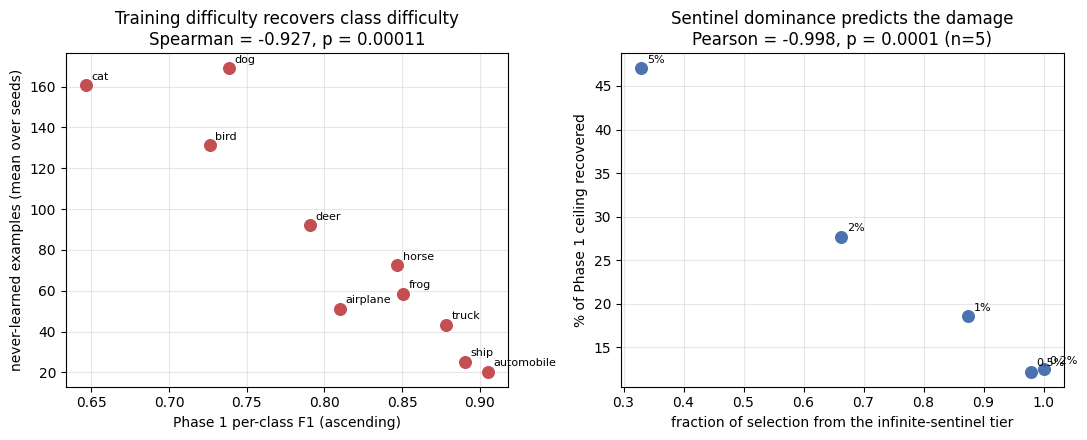


PRIMARY RESULT - mnist
(1) Does training difficulty recover Phase 1 class difficulty?

  aug    (PRIMARY   ) Spearman = -0.479  p = 0.16177   Pearson = -0.053  p = 0.88498   (n = 10 classes)
  clean  (robustness) Spearman = -0.337  p = 0.34083   Pearson = -0.034  p = 0.92647   (n = 10 classes)

  Variant agreement: Spearman(aug, clean) = +0.849 -- ordering is not an artefact of dropout/augmentation noise

  Per-class detail, hardest first:
    4            never-learned =     1.0   Phase 1 F1 = 0.9905
    7            never-learned =     0.2   Phase 1 F1 = 0.9826
    5            never-learned =     0.2   Phase 1 F1 = 0.9916
    6            never-learned =     0.2   Phase 1 F1 = 0.9887
    3            never-learned =     0.0   Phase 1 F1 = 0.9924
    2            never-learned =     0.0   Phase 1 F1 = 0.9918
    1            never-learned =     0.0   Phase 1 F1 = 0.9947
    0            never-learned =     0.0   Phase 1 F1 = 0.9926
    8            never-learned =     0.0   Phase 1 

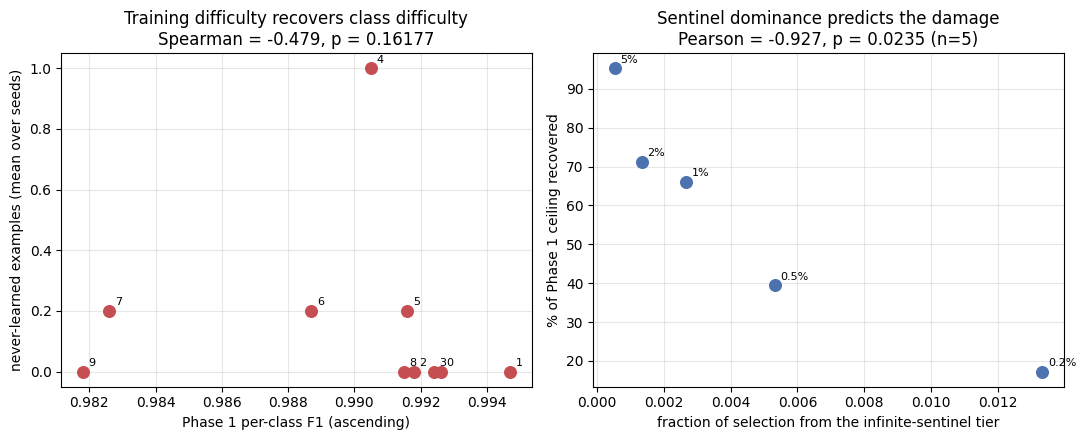

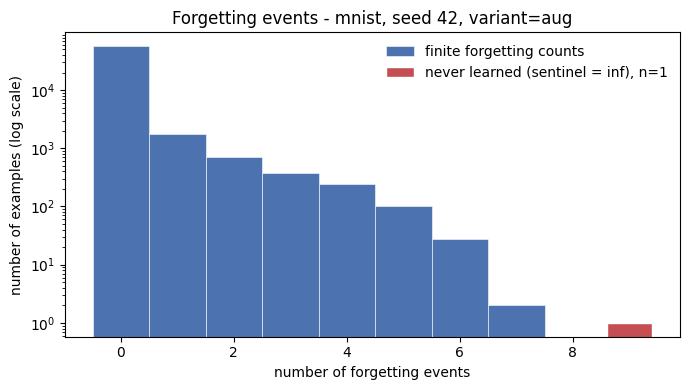

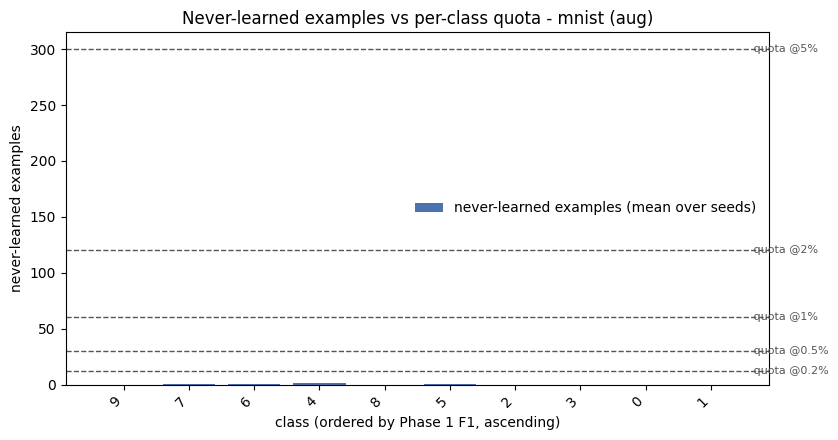

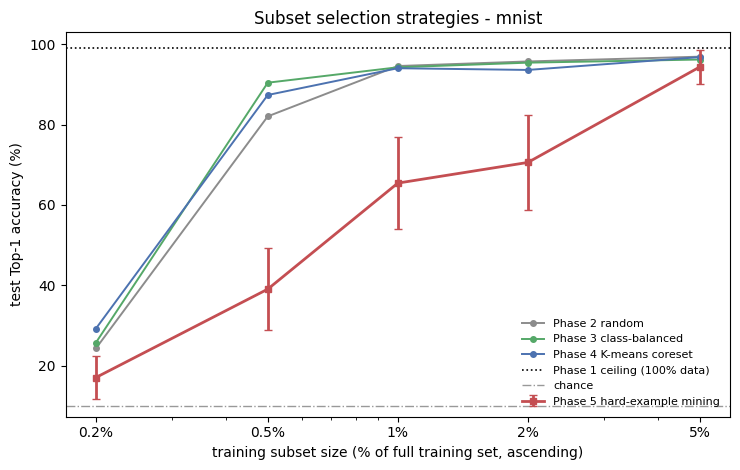

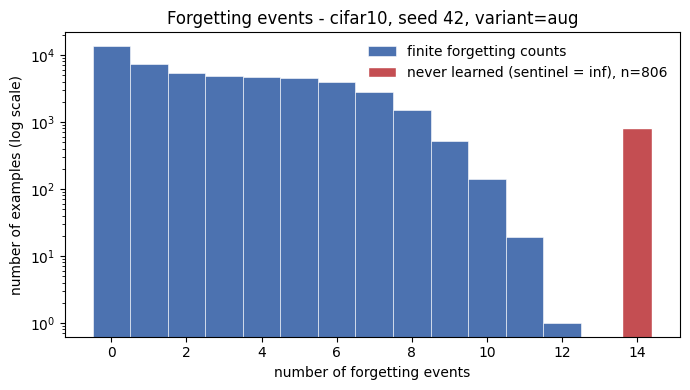

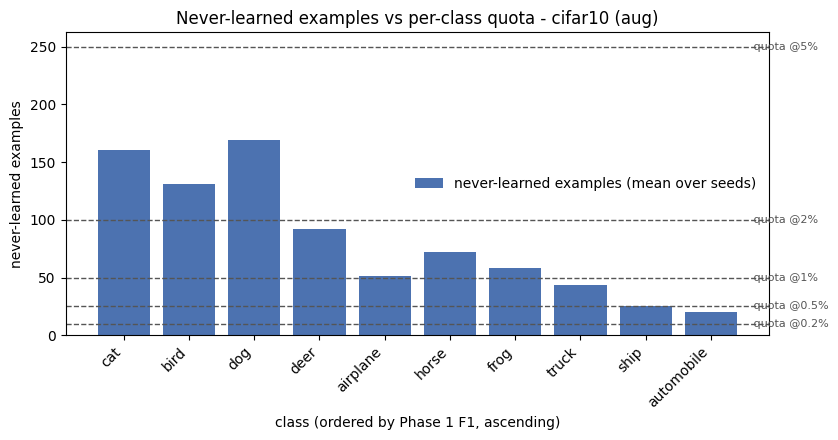

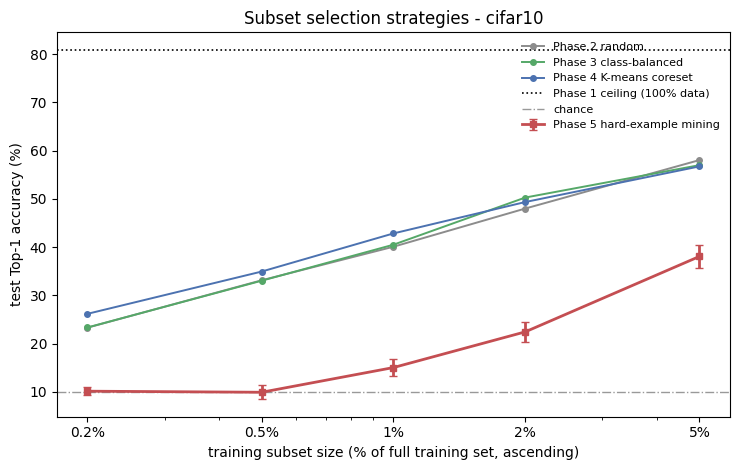

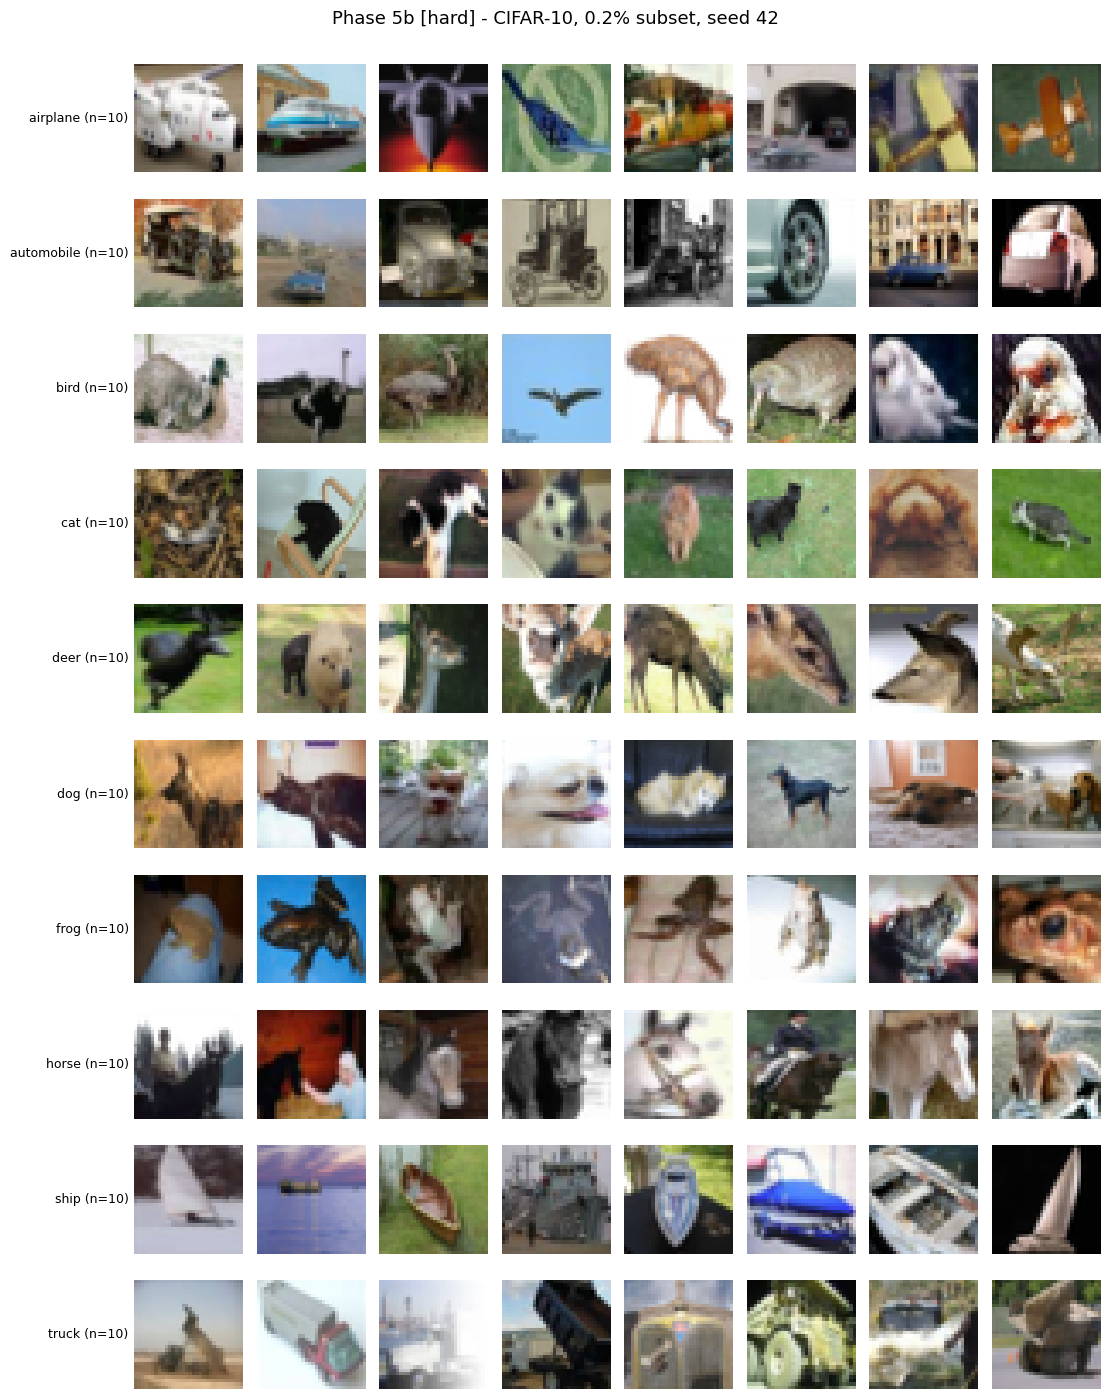

Saved: /kaggle/working/phase5/figures/fig_selection_grid_hard_cifar10_0.002.png


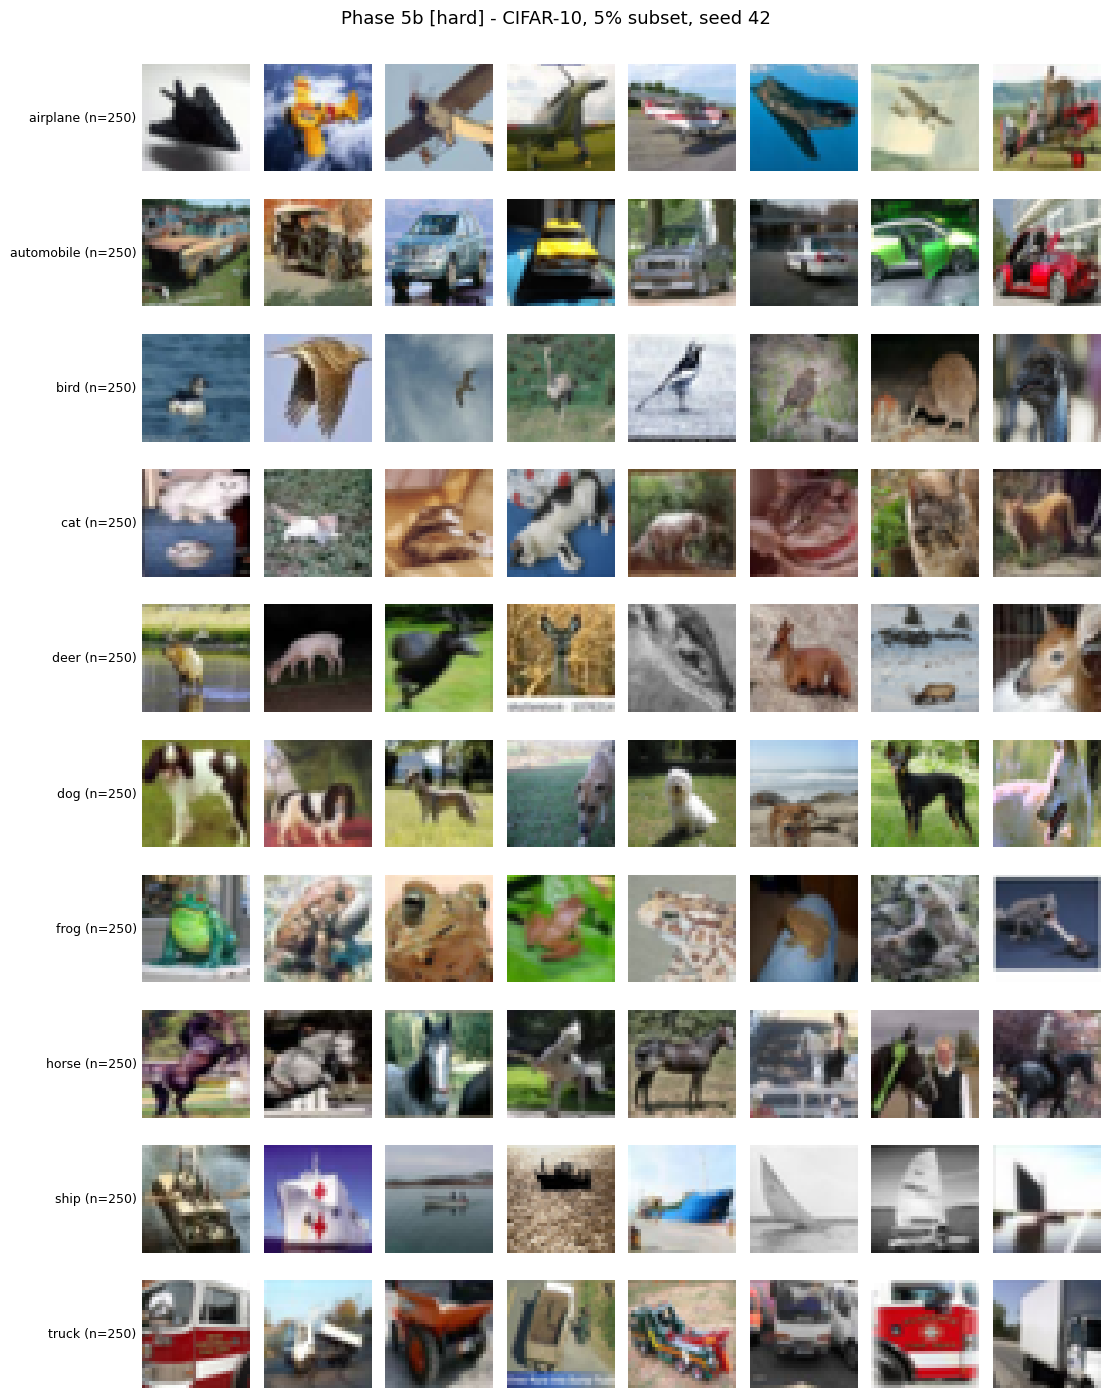

Saved: /kaggle/working/phase5/figures/fig_selection_grid_hard_cifar10_0.05.png

saved -> /kaggle/working/phase5/results/phase5b_hard_results.json

##############################################################################
# ARM: easy
##############################################################################

INSTRUMENTED RUN - mnist
  [mnist s42] cached -> forgetting_mnist_seed42_e20_db554d58b3.npz
  [mnist s123] cached -> forgetting_mnist_seed123_e20_db554d58b3.npz
  [mnist s456] cached -> forgetting_mnist_seed456_e20_db554d58b3.npz
  [mnist s789] cached -> forgetting_mnist_seed789_e20_db554d58b3.npz
  [mnist s1011] cached -> forgetting_mnist_seed1011_e20_db554d58b3.npz

Selection tests - mnist, seed 42
  f=0.002  n=120   quota/class=12   unique OK  balanced OK  deterministic OK
  f=0.005  n=300   quota/class=30   unique OK  balanced OK  deterministic OK
  f=0.01   n=600   quota/class=60   unique OK  balanced OK  deterministic OK
  f=0.02   n=1200  quota/class=120  unique OK  

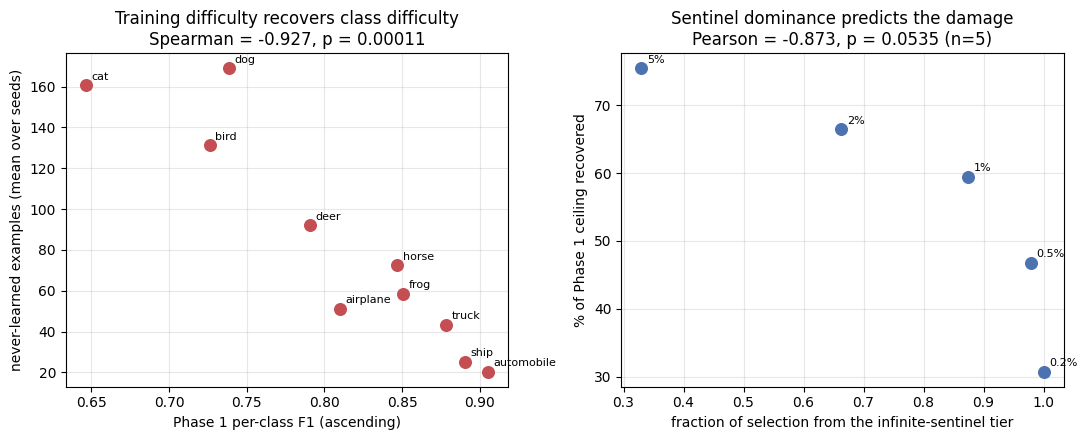


PRIMARY RESULT - mnist
(1) Does training difficulty recover Phase 1 class difficulty?

  aug    (PRIMARY   ) Spearman = -0.479  p = 0.16177   Pearson = -0.053  p = 0.88498   (n = 10 classes)
  clean  (robustness) Spearman = -0.337  p = 0.34083   Pearson = -0.034  p = 0.92647   (n = 10 classes)

  Variant agreement: Spearman(aug, clean) = +0.849 -- ordering is not an artefact of dropout/augmentation noise

  Per-class detail, hardest first:
    4            never-learned =     1.0   Phase 1 F1 = 0.9905
    7            never-learned =     0.2   Phase 1 F1 = 0.9826
    5            never-learned =     0.2   Phase 1 F1 = 0.9916
    6            never-learned =     0.2   Phase 1 F1 = 0.9887
    3            never-learned =     0.0   Phase 1 F1 = 0.9924
    2            never-learned =     0.0   Phase 1 F1 = 0.9918
    1            never-learned =     0.0   Phase 1 F1 = 0.9947
    0            never-learned =     0.0   Phase 1 F1 = 0.9926
    8            never-learned =     0.0   Phase 1 

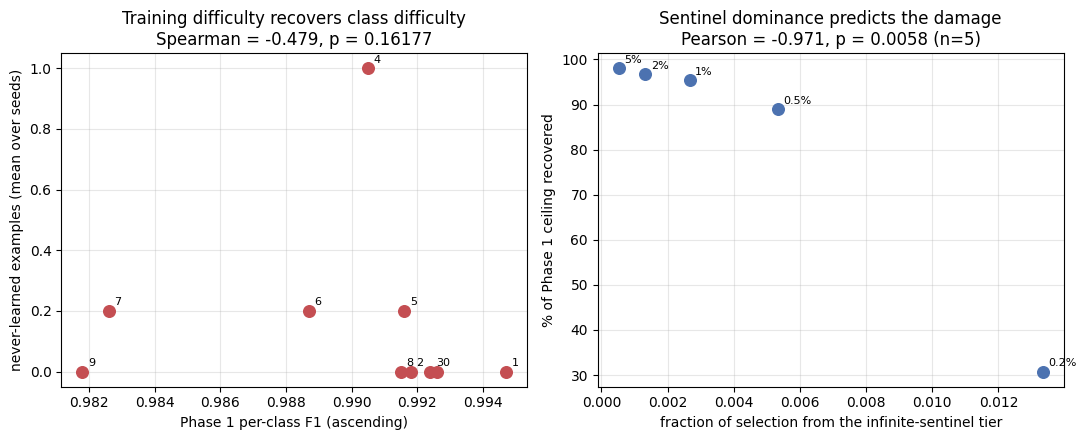

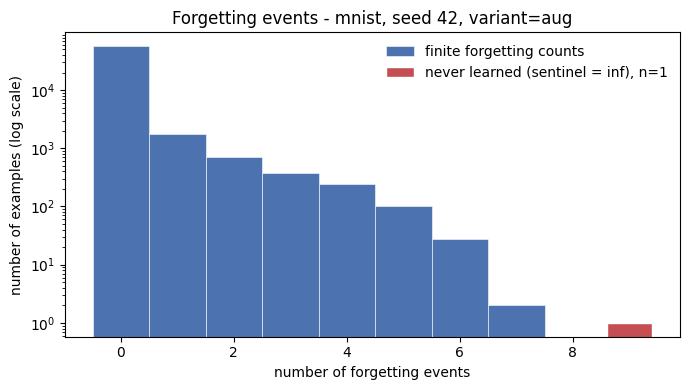

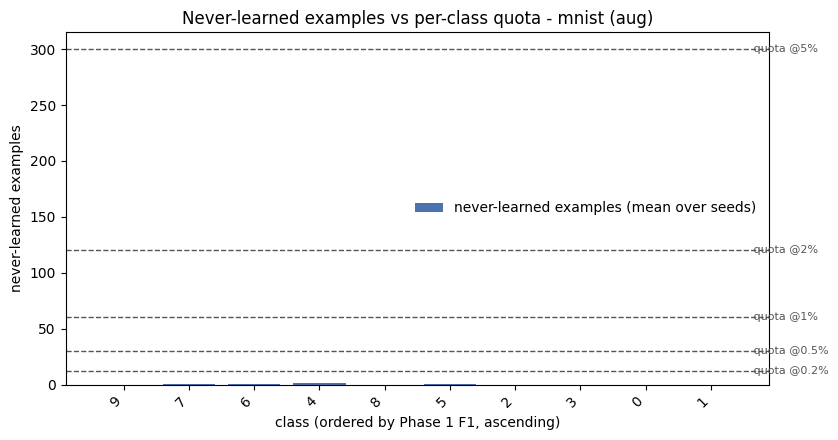

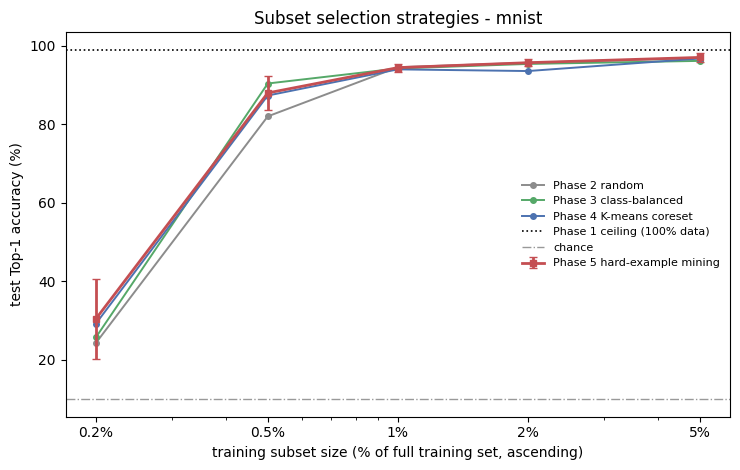

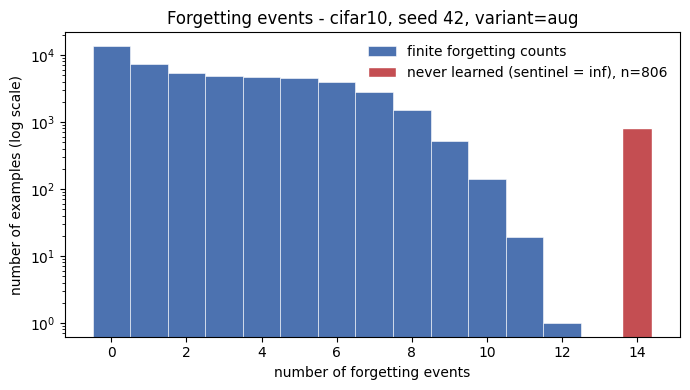

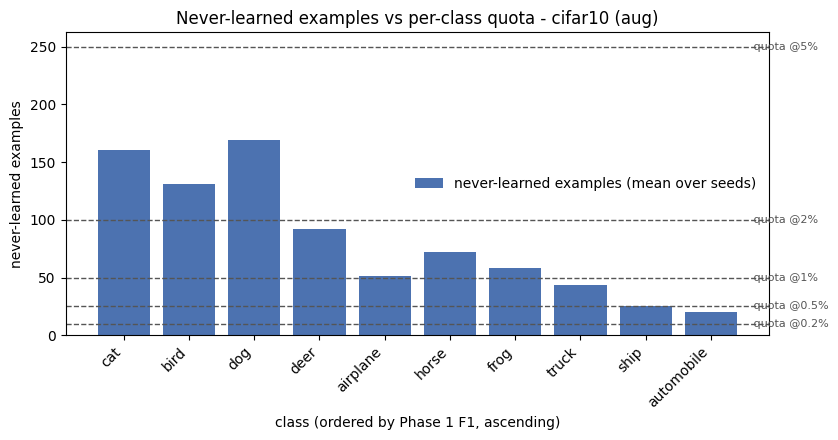

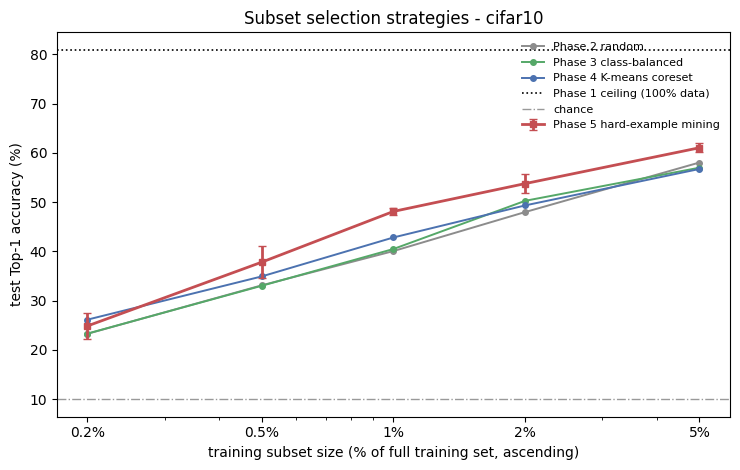

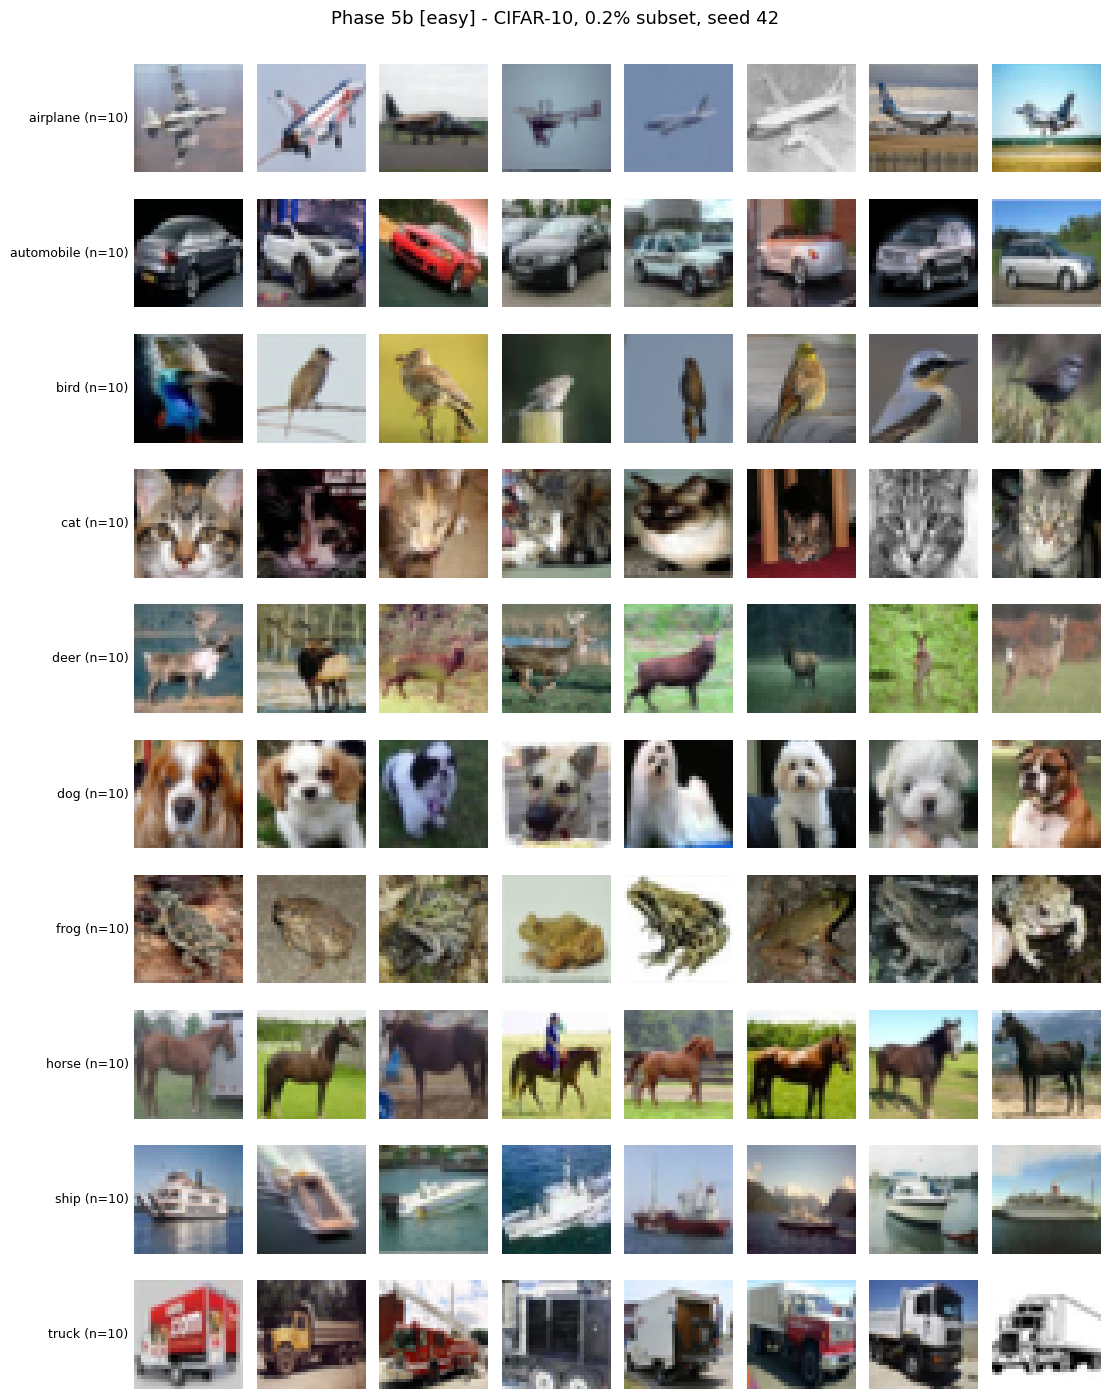

Saved: /kaggle/working/phase5/figures/fig_selection_grid_easy_cifar10_0.002.png


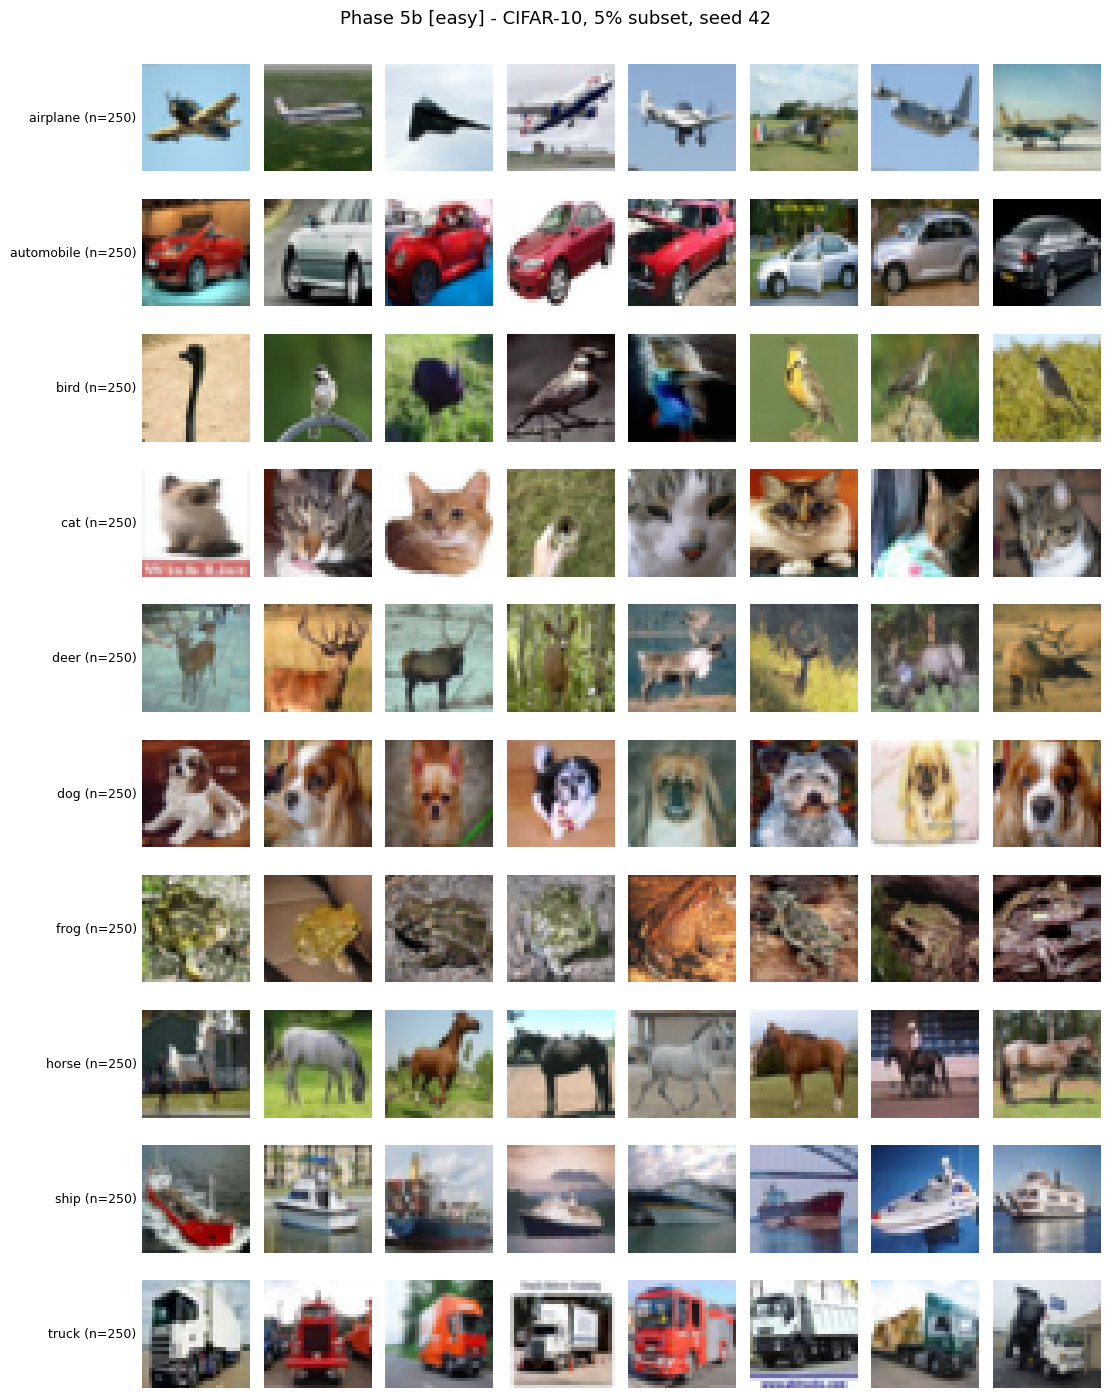

Saved: /kaggle/working/phase5/figures/fig_selection_grid_easy_cifar10_0.05.png

saved -> /kaggle/working/phase5/results/phase5b_easy_results.json

##############################################################################
# ARM: mid
##############################################################################

INSTRUMENTED RUN - mnist
  [mnist s42] cached -> forgetting_mnist_seed42_e20_db554d58b3.npz
  [mnist s123] cached -> forgetting_mnist_seed123_e20_db554d58b3.npz
  [mnist s456] cached -> forgetting_mnist_seed456_e20_db554d58b3.npz
  [mnist s789] cached -> forgetting_mnist_seed789_e20_db554d58b3.npz
  [mnist s1011] cached -> forgetting_mnist_seed1011_e20_db554d58b3.npz

Selection tests - mnist, seed 42
  f=0.002  n=120   quota/class=12   unique OK  balanced OK  deterministic OK
  f=0.005  n=300   quota/class=30   unique OK  balanced OK  deterministic OK
  f=0.01   n=600   quota/class=60   unique OK  balanced OK  deterministic OK
  f=0.02   n=1200  quota/class=120  unique OK  b

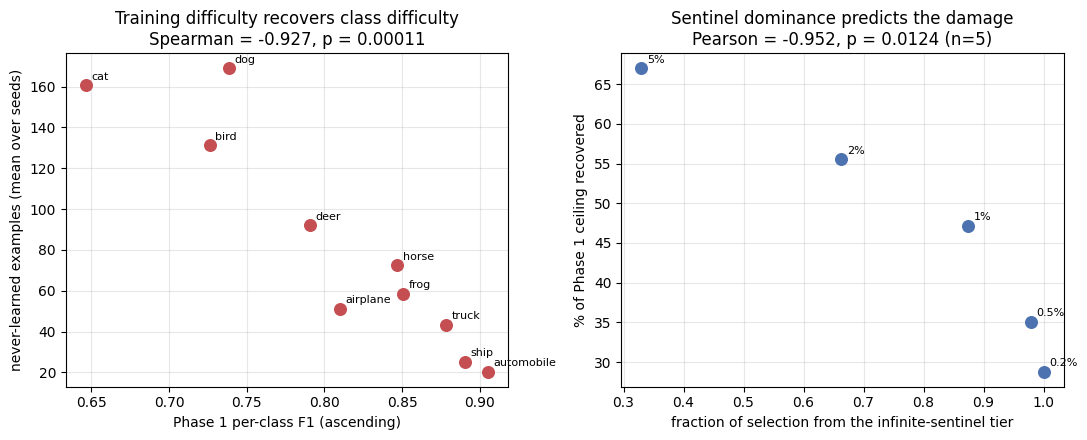


PRIMARY RESULT - mnist
(1) Does training difficulty recover Phase 1 class difficulty?

  aug    (PRIMARY   ) Spearman = -0.479  p = 0.16177   Pearson = -0.053  p = 0.88498   (n = 10 classes)
  clean  (robustness) Spearman = -0.337  p = 0.34083   Pearson = -0.034  p = 0.92647   (n = 10 classes)

  Variant agreement: Spearman(aug, clean) = +0.849 -- ordering is not an artefact of dropout/augmentation noise

  Per-class detail, hardest first:
    4            never-learned =     1.0   Phase 1 F1 = 0.9905
    7            never-learned =     0.2   Phase 1 F1 = 0.9826
    5            never-learned =     0.2   Phase 1 F1 = 0.9916
    6            never-learned =     0.2   Phase 1 F1 = 0.9887
    3            never-learned =     0.0   Phase 1 F1 = 0.9924
    2            never-learned =     0.0   Phase 1 F1 = 0.9918
    1            never-learned =     0.0   Phase 1 F1 = 0.9947
    0            never-learned =     0.0   Phase 1 F1 = 0.9926
    8            never-learned =     0.0   Phase 1 

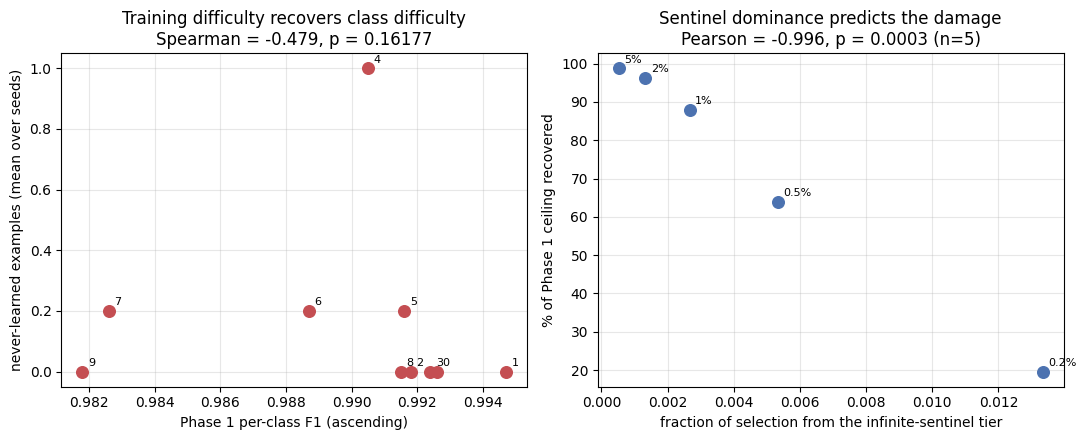

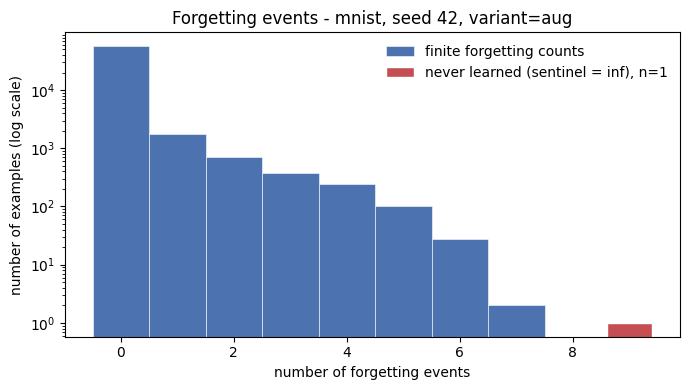

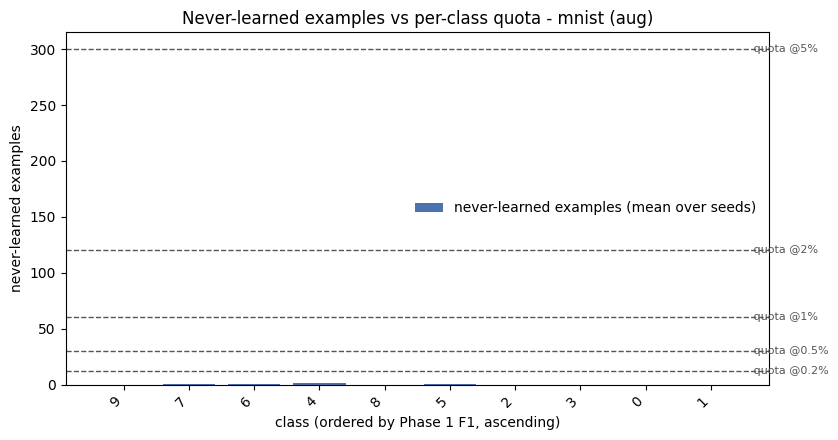

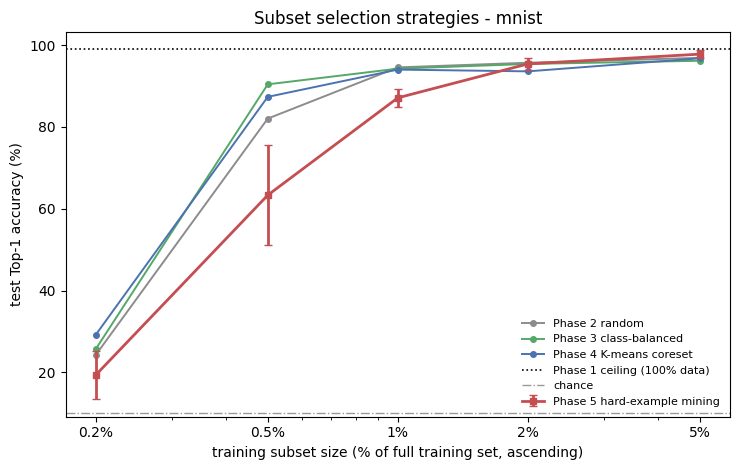

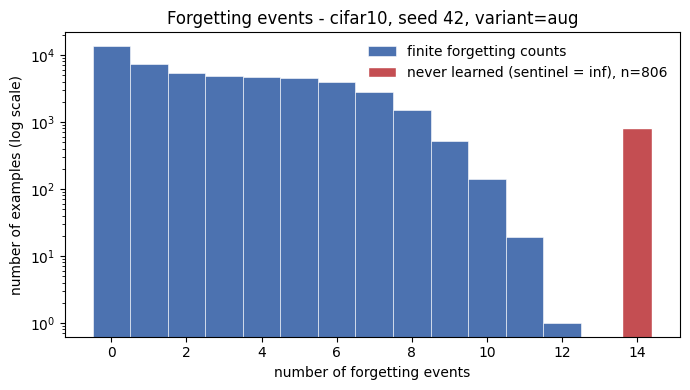

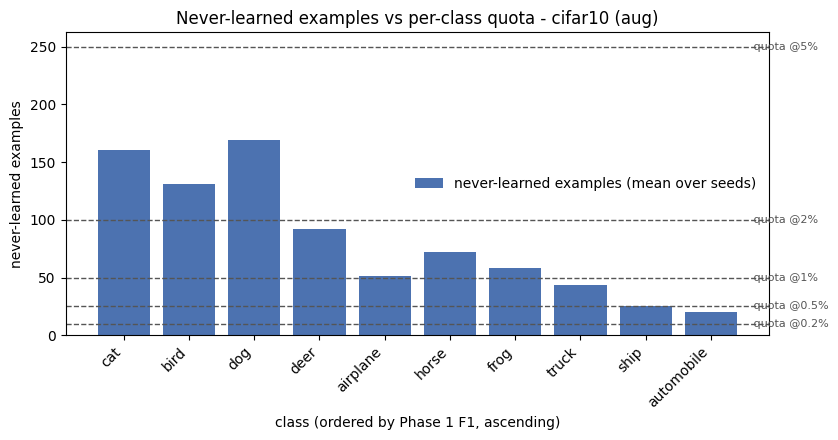

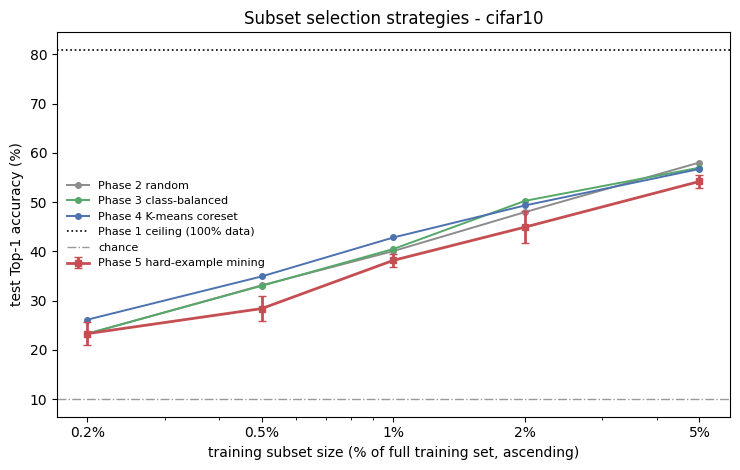

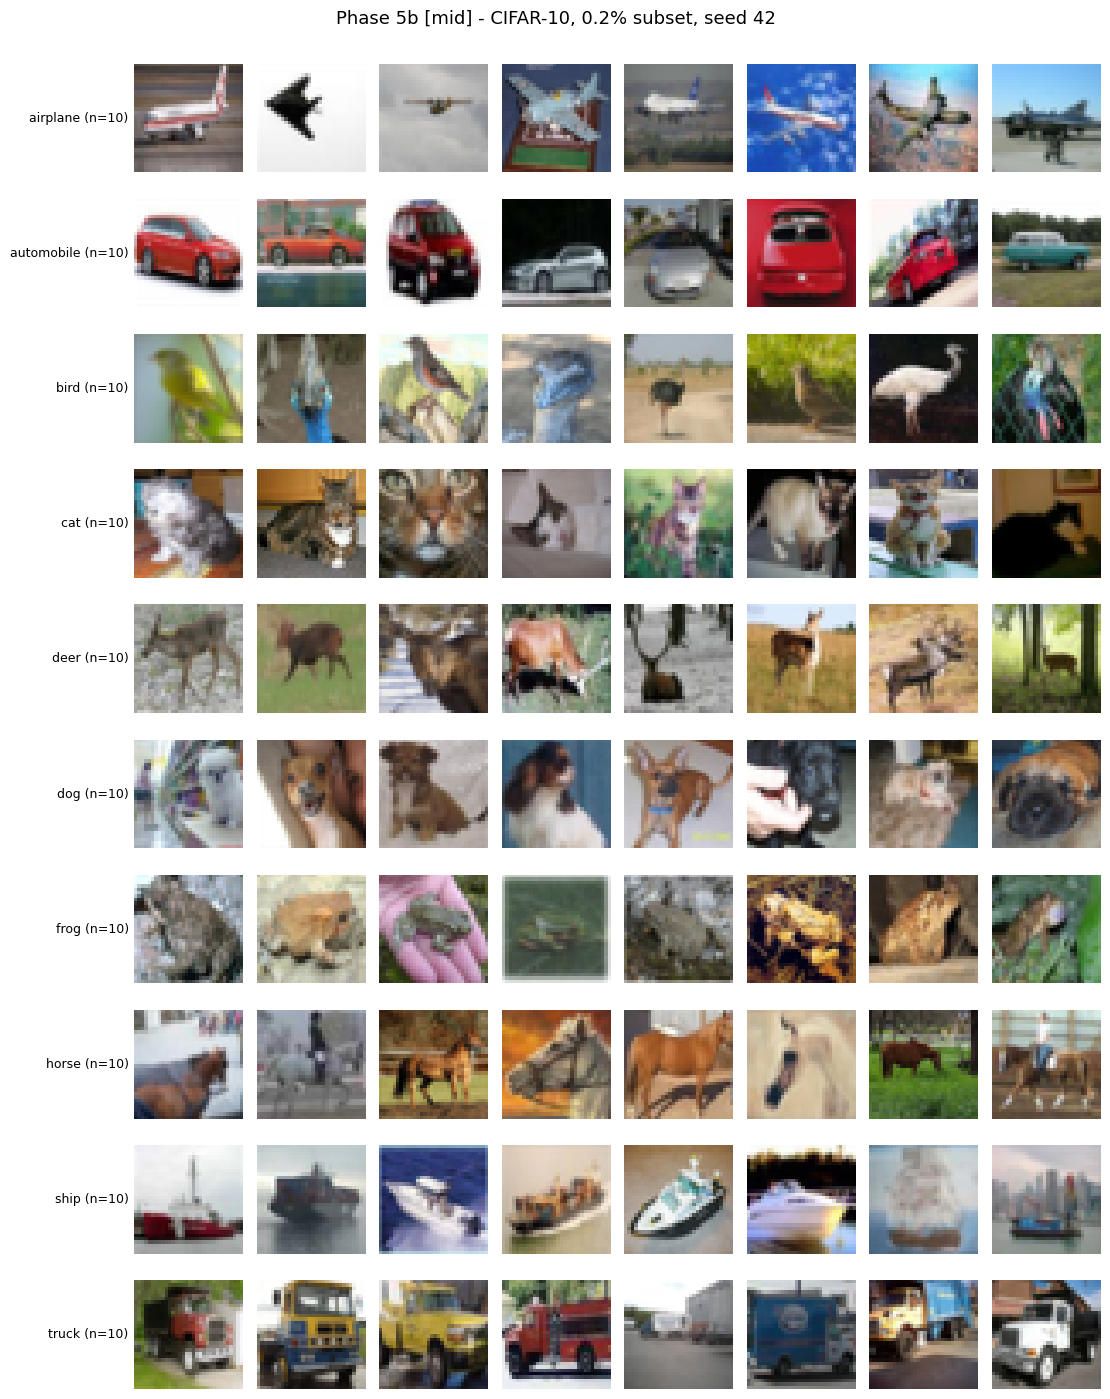

Saved: /kaggle/working/phase5/figures/fig_selection_grid_mid_cifar10_0.002.png


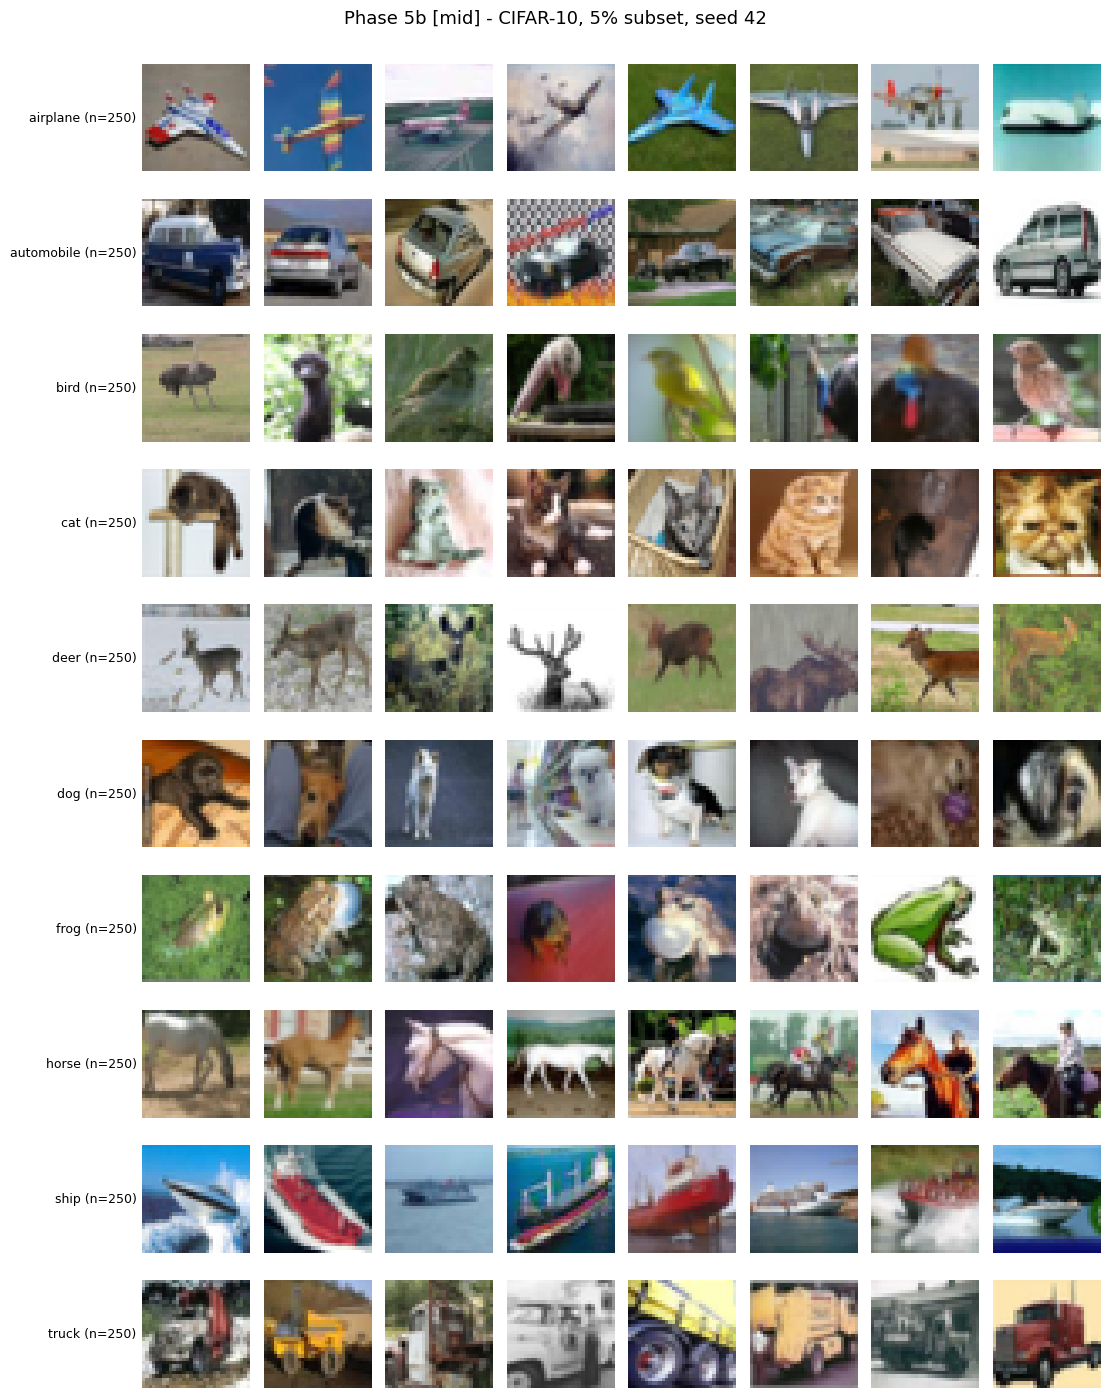

Saved: /kaggle/working/phase5/figures/fig_selection_grid_mid_cifar10_0.05.png

saved -> /kaggle/working/phase5/results/phase5b_mid_results.json

##############################################################################
# ARM: hard_ns
##############################################################################

INSTRUMENTED RUN - mnist
  [mnist s42] cached -> forgetting_mnist_seed42_e20_db554d58b3.npz
  [mnist s123] cached -> forgetting_mnist_seed123_e20_db554d58b3.npz
  [mnist s456] cached -> forgetting_mnist_seed456_e20_db554d58b3.npz
  [mnist s789] cached -> forgetting_mnist_seed789_e20_db554d58b3.npz
  [mnist s1011] cached -> forgetting_mnist_seed1011_e20_db554d58b3.npz

Selection tests - mnist, seed 42
  f=0.002  n=120   quota/class=12   unique OK  balanced OK  deterministic OK
  f=0.005  n=300   quota/class=30   unique OK  balanced OK  deterministic OK
  f=0.01   n=600   quota/class=60   unique OK  balanced OK  deterministic OK
  f=0.02   n=1200  quota/class=120  unique OK 

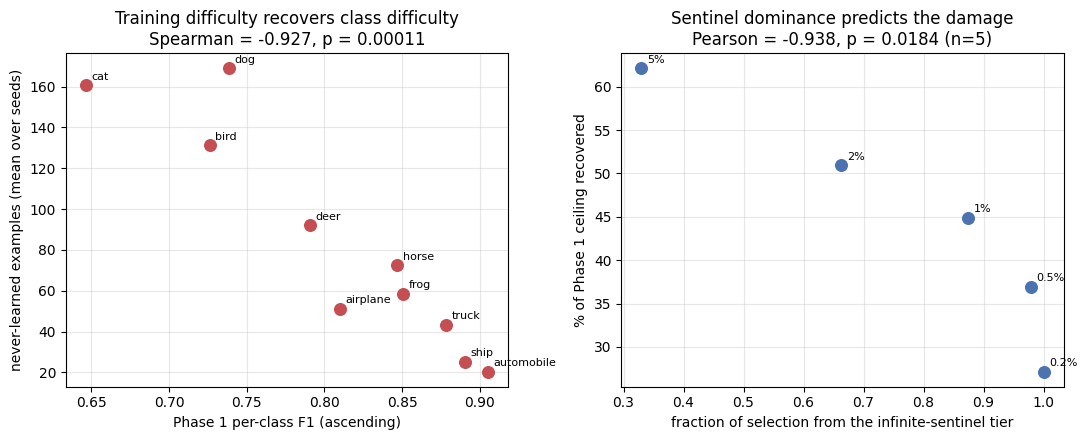


PRIMARY RESULT - mnist
(1) Does training difficulty recover Phase 1 class difficulty?

  aug    (PRIMARY   ) Spearman = -0.479  p = 0.16177   Pearson = -0.053  p = 0.88498   (n = 10 classes)
  clean  (robustness) Spearman = -0.337  p = 0.34083   Pearson = -0.034  p = 0.92647   (n = 10 classes)

  Variant agreement: Spearman(aug, clean) = +0.849 -- ordering is not an artefact of dropout/augmentation noise

  Per-class detail, hardest first:
    4            never-learned =     1.0   Phase 1 F1 = 0.9905
    7            never-learned =     0.2   Phase 1 F1 = 0.9826
    5            never-learned =     0.2   Phase 1 F1 = 0.9916
    6            never-learned =     0.2   Phase 1 F1 = 0.9887
    3            never-learned =     0.0   Phase 1 F1 = 0.9924
    2            never-learned =     0.0   Phase 1 F1 = 0.9918
    1            never-learned =     0.0   Phase 1 F1 = 0.9947
    0            never-learned =     0.0   Phase 1 F1 = 0.9926
    8            never-learned =     0.0   Phase 1 

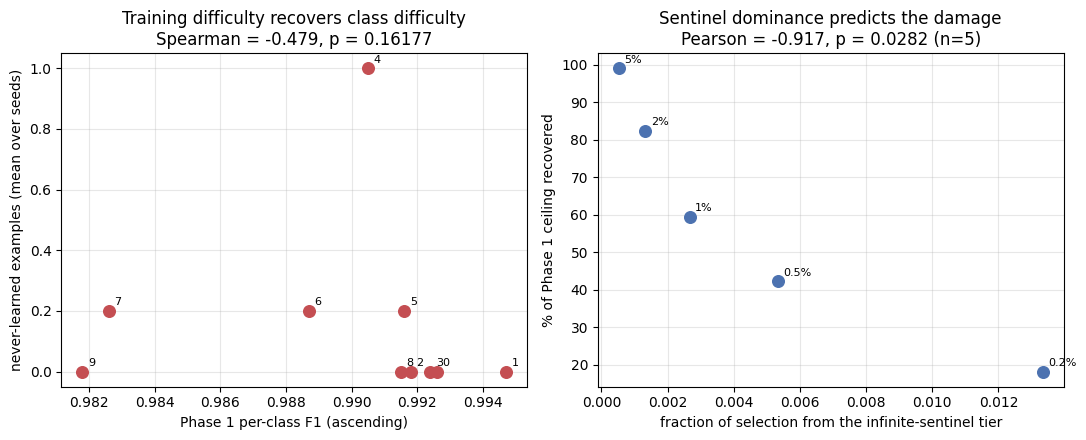

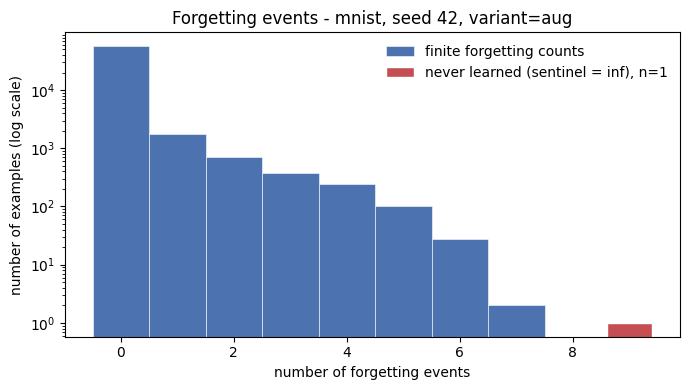

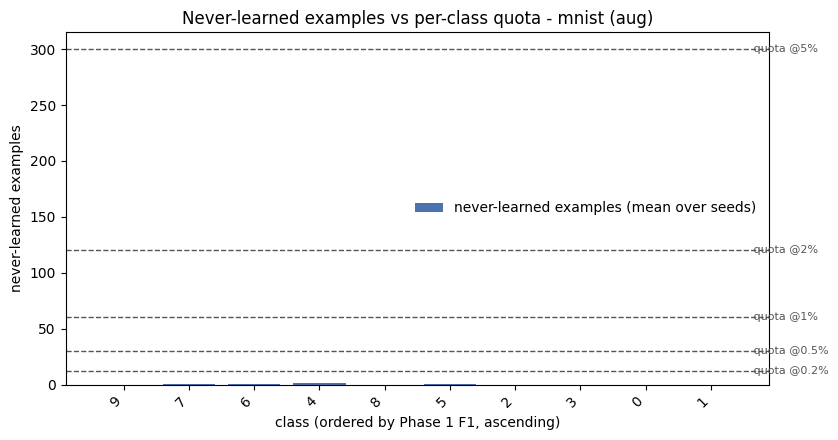

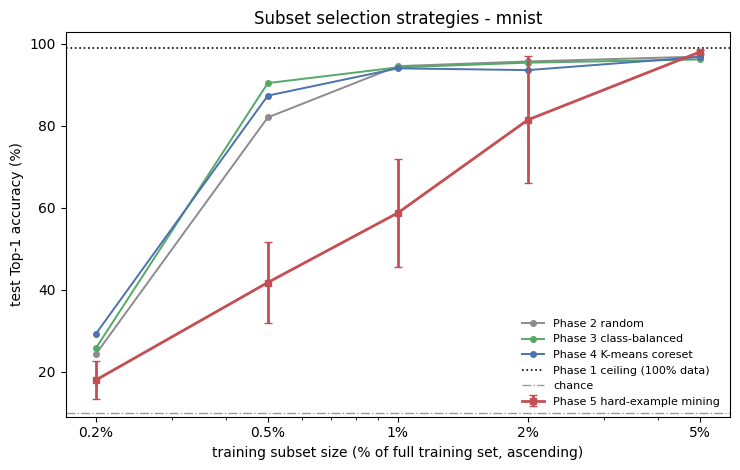

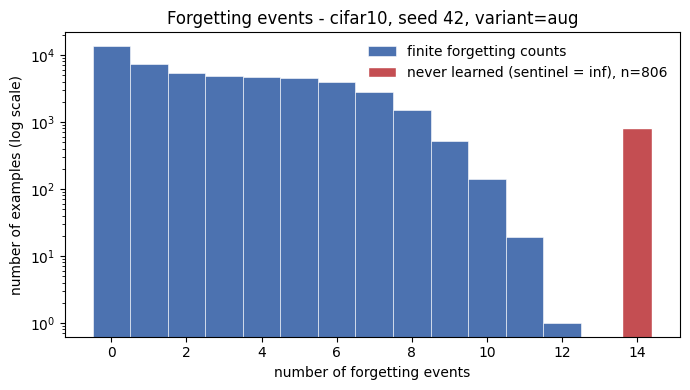

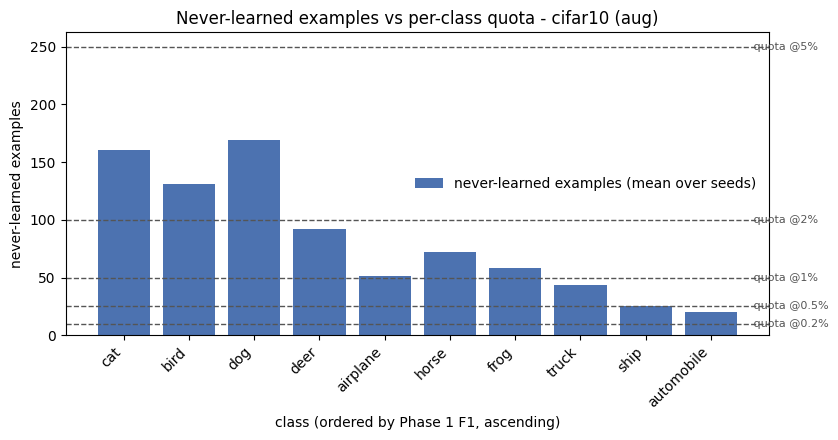

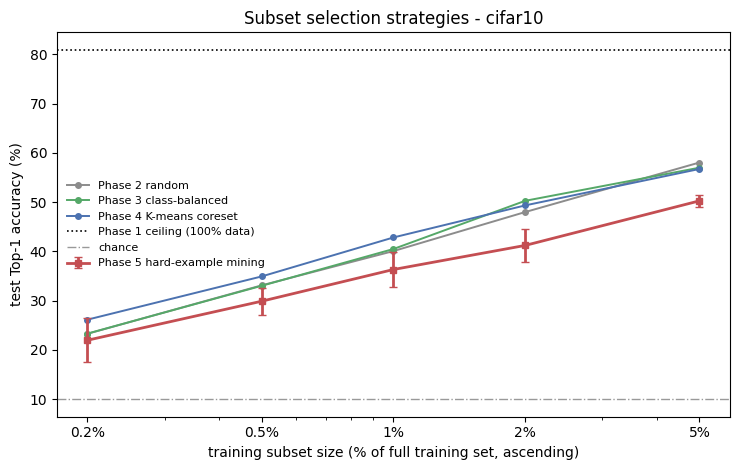

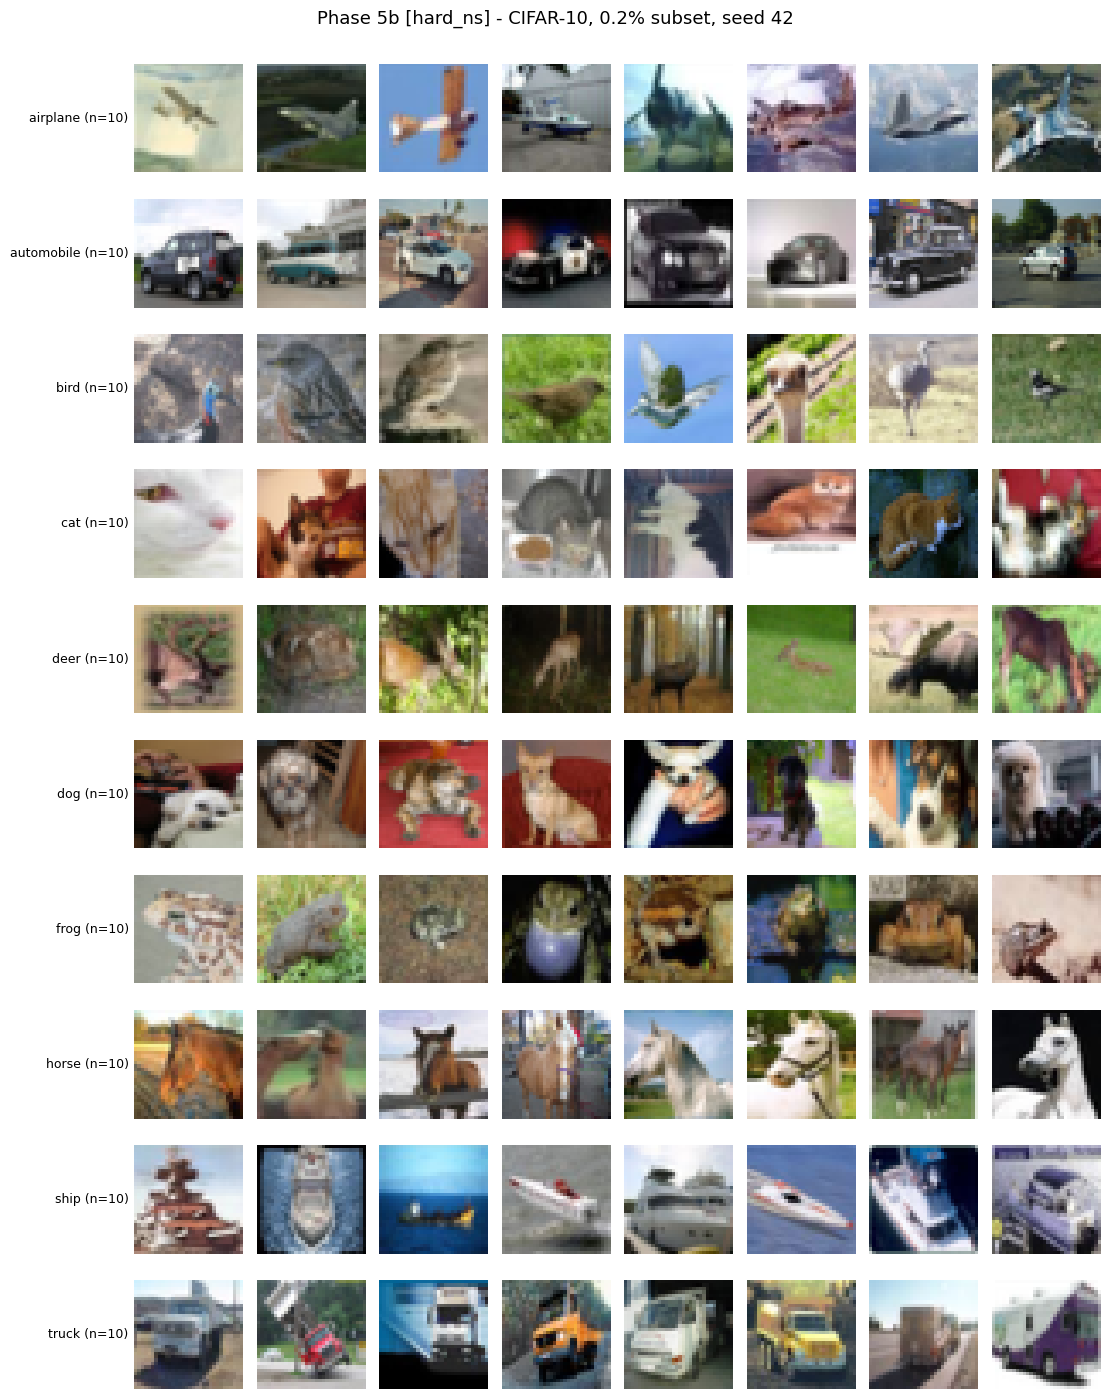

Saved: /kaggle/working/phase5/figures/fig_selection_grid_hard_ns_cifar10_0.002.png


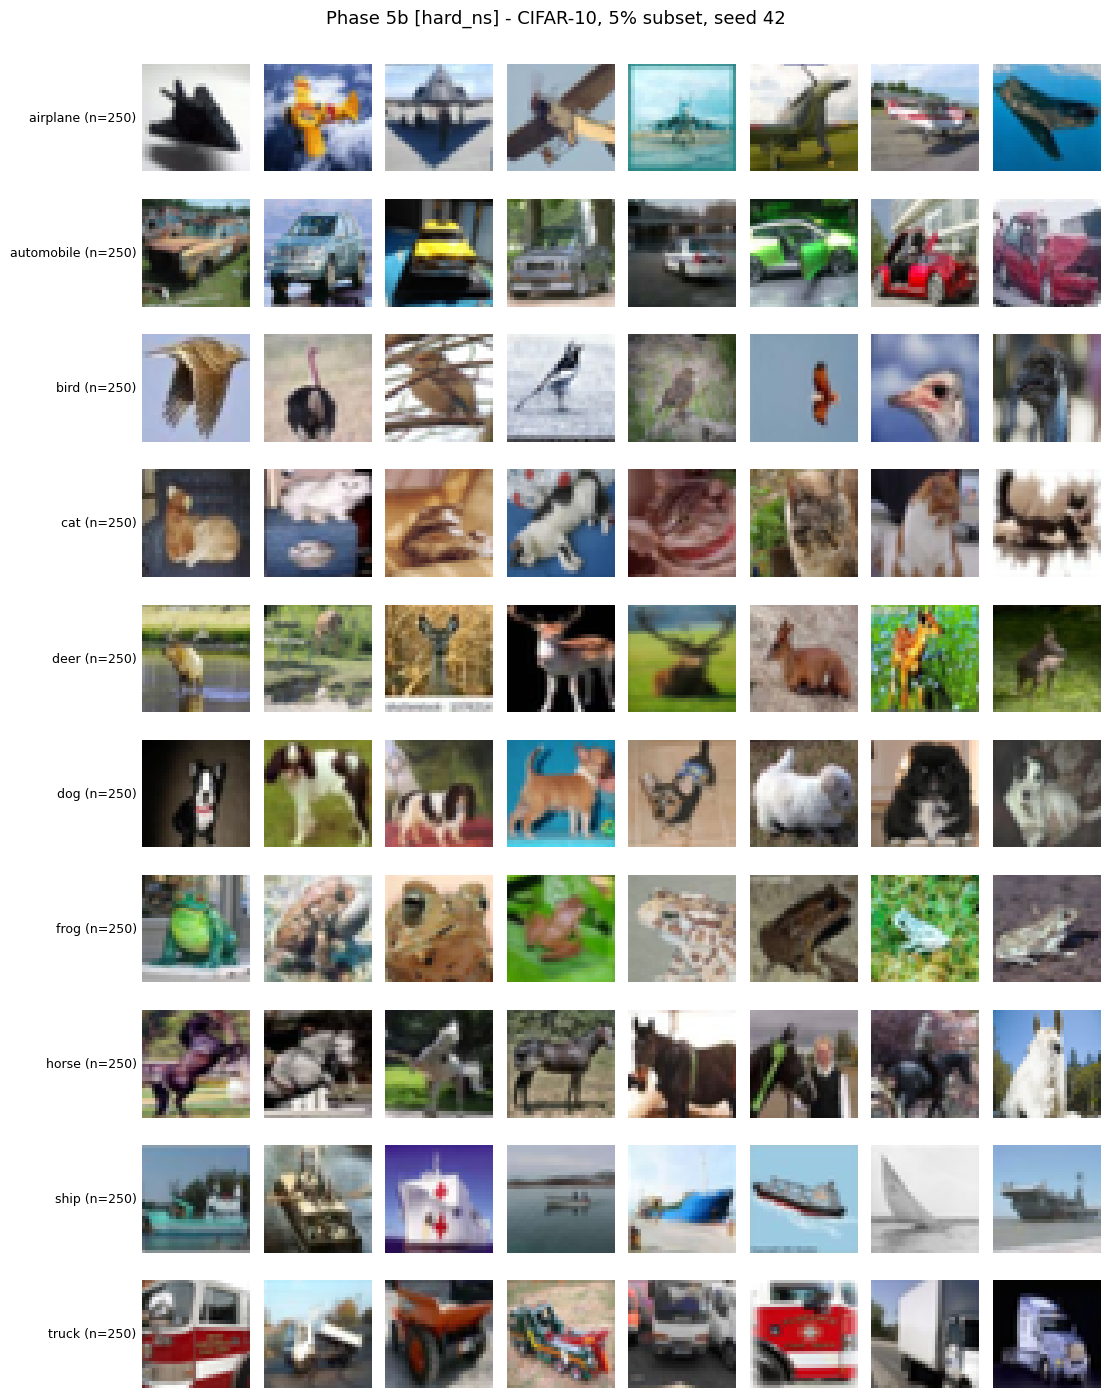

Saved: /kaggle/working/phase5/figures/fig_selection_grid_hard_ns_cifar10_0.05.png

saved -> /kaggle/working/phase5/results/phase5b_hard_ns_results.json

PHASE 5b ARMS - cifar10 (Phase 1 ceiling 80.93)
   frac   P3 bal       hard       easy        mid    hard_ns
  0.002    23.33      10.11      24.88      23.32      21.98
  0.005    33.03       9.89      37.82      28.40      29.90
  0.010    40.50      15.01      48.12      38.20      36.33
  0.020    50.28      22.42      53.78      44.95      41.23
  0.050    57.00      38.06      61.05      54.21      50.27

Delta vs Phase 3 (pp):
   frac       hard       easy        mid    hard_ns
  0.002     -13.22      +1.55      -0.01      -1.35
  0.005     -23.14      +4.79      -4.63      -3.13
  0.010     -25.49      +7.62      -2.30      -4.17
  0.020     -27.86      +3.50      -5.33      -9.05
  0.050     -18.94      +4.05      -2.79      -6.73

PHASE 5b ARMS - mnist (Phase 1 ceiling 98.98)
   frac   P3 bal       hard       easy        mid 

In [6]:
preflight()      # loads full-epoch stats, checks distribution + arm overlap
run_all_arms()   # only if preflight is clean